# DiploDatos 2026- Mentoría "Deteccion de fraude: ¿Como cuido a mis clientes? Machine Learning aplicado a un caso de negocio financiero"

##Integrantes:
- Abagnale, Florencia
- Karlen Paula
- Luna Ana Maria
- Pintos Mauricio José

## <font color=blue> Trabajo Practico N° 1

##  Mentoría "Deteccion de fraude: ¿Como cuido a mis clientes? Machine Learning aplicado a un caso de negocio financiero"

## Analisis y Visualizacion de Datos (EDA)
### Entregable

● Los invito a desarrollar cada punto en la Notebook compartida que les sirve de guía para cumplir con este TP.

● Se debe subir el entregable a un repositorio GitHub o enviar el link a un Google Colab.

● Si bien seguramente se harán muchos análisis de diversos tipos y consideraciones, solo se debe dejar en la Notebook a entregar aquellos análisis que sean relevantes y que consideren de importancia según el tema a presentar.

● Recuerden siempre que luego de cada gráfico, cálculo, es importante describir brevemente que es lo que se está haciendo, y si son gráficos, a que conclusión han llegado, para expresar los comprendido y el nivel de profundidad alcanzada de los contenidos teóricos impartidos.

# Importar librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stat
import scipy.stats as st
from statistics import stdev
from scipy.stats import t
import datetime
import missingno as msno
import seaborn
import unicodedata
from scipy.stats import chi2_contingency
import itertools
from sklearn.feature_selection import mutual_info_classif


seaborn.set_context('talk')
sns.set_context('talk')

# Seteo de displays
pd.set_option('display.max_columns',10000)
pd.set_option('display.max_rows',10000)
pd.set_option('display.float_format', lambda x: '%.6f' % x)
pd.options.display.max_columns = None # para que no recorte las columnas

# Leer el dataset

In [ ]:
# subir el .xlsx
from google.colab import files
uploaded = files.upload()

Saving Dr_Muestra.xlsx to Dr_Muestra.xlsx


In [ ]:
# subir el .del
from google.colab import files
uploaded = files.upload()

Saving Muestra.del to Muestra.del


In [4]:
# Importamos el datset que definimmos

df = pd.read_csv ("Muestra.del", sep='|', encoding='latin-1')

## 1.	Familiarización con el dataset:

Para ello se deberá interpretar la documentación brindada donde se detalle el significado de cada variable, posteriormente se deberá importar los datos, analizar su estructura, tipos de campos, ver si hay datos faltantes.

In [5]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192664 entries, 0 to 192663
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Cliente_Id                192664 non-null  int64 
 1   Cliente_Sexo              160022 non-null  object
 2   Cliente_FechaNacimiento   192664 non-null  object
 3   Cliente_EstadoCivil       160022 non-null  object
 4   Cliente_CodigoPostal      192664 non-null  int64 
 5   Cliente_ActivoPlataforma  192664 non-null  object
 6   Cliente_Segmento          160022 non-null  object
 7   Cuenta_Producto           192664 non-null  object
 8   Movimiento_Tipo           192664 non-null  object
 9   Movimiento_Agrupa         192664 non-null  object
 10  Movimiento_SubAgrup       192664 non-null  object
 11  Movimiento_Codigo         192664 non-null  int64 
 12  Trx_RedLogicaTerminal     192664 non-null  object
 13  Trx_Rta                   192664 non-null  object
 14  Trx_

**Nuestro dataset cuenta con 192664 datos  y  26 variables, de las cuales 8 son Int64 (númericas de tipo entero) y 18 Object.**

Las variables son:

`Cliente_Id` ,Indica el número de Id del Cliente.

`Cliente_Sexo`,Sexo del Cliente.

`Cliente_FechaNacimiento`,Fecha de nacimiento del cliente.

`Cliente_EstadoCivil`,Estado civil del cliente.

`Cliente_CodigoPostal`,Codigo Postal del cliente.

`Cliente_ActivoPlataforma`,Es usuario activo de la plataforma.

`Cliente_Segmento`,Corresponde a la categoria asignada por el banco al cliente según la cuenta que usa.

`Cuenta_Producto`,Corresponde al identificador del tipo de cuenta.

`Movimiento_Tipo`,Corresponde al identificador del tipo de movimiento.

`Movimiento_Agrupa`,"Corresponde al tipo de movimiento para agrupación.

`Movimiento_SubAgrup`,Corresponde al identificador del subtipo de producto contable relacionado al movimiento.

`Movimiento_Codigo`,Código de movimiento al que corresponde la transacción.

`Trx_RedLogicaTerminal`,"Nombre de la red lógica asociada con la terminal (ATM). es el identificador de la red de procesamiento por la cual viaja la transacción. Indica qué ""carretera"" digital usó el banco para autorizar el pago.

`Trx_Rta`,Indica donde se responde la transacción que fue generada.

`Trx_TipoTerminal`,Tipo de terminal.

`Trx_terminalRed`,D de la Terminal con una transformada aplicada.

`Trx_RubroRed`,codigo de rubro del comercio donde se efectuo la compra.

`Trx_CiudadTerminal`,Ciudad donde está instalada la Terminal.

`Trx_ModoIngreso`,Clasificación de terminal según STATUS EMV.

`Trx_EsChip`,Indicador de tarjeta Chip.

`Trx_Estado`,"Indica el tipo de transacción según si ha sido aprobada, reversada o corresponde a una transacción interna.

`Trx_Fecha`,Fecha calendario de la transacción.

`Trx_Hora`,Hora de la transacción.

`Trx_Moneda`,Corresponde a la moneda en la que ingresó la operación.

`Trx_Importe`,Monto requerido de la transacción.

`Es_Fraude`,Indica si el movimiento es fraude.




In [6]:
df.head()

,Cliente_Id,Cliente_Sexo,Cliente_FechaNacimiento,Cliente_EstadoCivil,Cliente_CodigoPostal,Cliente_ActivoPlataforma,Cliente_Segmento,Cuenta_Producto,Movimiento_Tipo,Movimiento_Agrupa,Movimiento_SubAgrup,Movimiento_Codigo,Trx_RedLogicaTerminal,Trx_Rta,Trx_TipoTerminal,Trx_TerminalRed,Trx_RubroRed,Trx_CiudadTerminal,Trx_ModoIngreso,Trx_EsChip,Trx_Estado,Trx_Fecha,Trx_Hora,Trx_Moneda,Trx_Importe,Es_Fraude
0,19,NaN,6/12/1948,NaN,5021,Si,NaN,CajaAhorro,D,A11,SA06,1050,C,SI,11,4231303838303233,5969,CAPITAL FEDER,A,N,A,250820,10473300,1,"35999,98",NO
1,19,MASCULINO,6/12/1948,CASADO/A,5021,Si,S2,CajaAhorro,D,A11,SA06,1050,C,SI,0,3645394244463336,5499,CORDOBA,F,S,A,251014,12284100,1,"33000,00",NO
2,19,MASCULINO,6/12/1948,CASADO/A,5021,Si,S2,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,CORDOBA,E,S,A,251111,18401316,1,"100000,00",NO
3,19,MASCULINO,6/12/1948,CASADO/A,5021,Si,S2,CajaAhorro,D,A11,SA06,1050,C,SI,11,4231303838303233,5969,CAPITAL FEDER,A,N,A,251022,10163200,1,"35999,99",NO
4,19,MASCULINO,6/12/1948,CASADO/A,5021,Si,S2,CajaAhorro,D,A11,SA06,1050,C,SI,7,3535443543393239,4899,CABA,A,N,A,251101,7150400,1,"24158,49",NO


Visualizamos 5 transacciones realizadas por el usuario identificado como: cliente_Id 19, **se observan columnas con datos faltantes,  y variables con Dtype mal asignado (Cliente_FechaNacimiento y Trx_Fecha debería ser de tipo fecha e Trx_Importe).**


In [7]:
# Valores nulos
nulos = df.isna().sum()
nulos[nulos > 0].sort_values(ascending=False)

Cliente_Sexo           32642
Cliente_EstadoCivil    32642
Cliente_Segmento       32642
Trx_CiudadTerminal      5721
dtype: int64

Exiten cuatro variables con datos nulos, tres de ellas coinciden en la cantidad de valores nulos,  lo que puede significar que correspondan a los mismos clientes. Análisis que realizaremos posteriormente.

In [8]:
df.describe()

,Cliente_Id,Cliente_CodigoPostal,Movimiento_Codigo,Trx_TipoTerminal,Trx_RubroRed,Trx_Fecha,Trx_Hora,Trx_Moneda
count,192664.000000,192664.000000,192664.000000,192664.000000,192664.000000,192664.000000,192664.000000,192664.000000
mean,378.335558,4908.238628,1042.545660,3.618979,2741.333944,250670.103356,14346534.861220,1.031038
std,203.380774,973.622041,8.538547,3.839279,3099.142471,340.151337,5109833.482483,0.173422
min,1.000000,1013.000000,1010.000000,0.000000,-1.000000,250101.000000,0.000000,1.000000
25%,217.000000,5000.000000,1038.000000,0.000000,-1.000000,250403.000000,11010600.000000,1.000000
50%,378.000000,5004.000000,1049.000000,3.000000,-1.000000,250704.000000,14033316.500000,1.000000
75%,543.000000,5194.000000,1050.000000,7.000000,5462.000000,251001.000000,18554000.000000,1.000000
max,757.000000,6275.000000,1065.000000,12.000000,9399.000000,251231.000000,23595935.000000,2.000000


Se realiza una descripción estadística de las variables numéricas.

In [9]:
#Corrección de datos
# Importe: Cambiamos , por .
df['Trx_Importe'] = df['Trx_Importe'].str.replace(',', '.').astype(float)

# Fecha transacción: AAMMDD -> datetime
df['Trx_Fecha'] = pd.to_datetime(df['Trx_Fecha'], format='%y%m%d')

# Fecha nacimiento: dd/mm/aaaa -> datetime
df['Cliente_FechaNacimiento'] = pd.to_datetime(df['Cliente_FechaNacimiento'], format='%d/%m/%Y')

# Hora: hhmmssxx -> hh:mm:ss
df['Trx_Hora'] = df['Trx_Hora'].astype(str).str.zfill(8)
df['Trx_Hora_fmt'] = df['Trx_Hora'].str[:6]
df['Trx_Hora_fmt'] = pd.to_datetime(df['Trx_Hora_fmt'], format='%H%M%S', errors='coerce').dt.time

df[['Trx_Hora','Cliente_FechaNacimiento','Trx_Hora_fmt',]].head()

,Trx_Hora,Cliente_FechaNacimiento,Trx_Hora_fmt
0,10473300,1948-12-06,10:47:33
1,12284100,1948-12-06,12:28:41
2,18401316,1948-12-06,18:40:13
3,10163200,1948-12-06,10:16:32
4,07150400,1948-12-06,07:15:04


In [10]:
#Variable objetivo

df['Es_Fraude'].value_counts()
df['Es_Fraude'].value_counts(normalize=True) * 100

Es_Fraude
NO   99.379230
SI    0.620770
Name: proportion, dtype: float64

En nuestro dataset, más del 99% de los registros no son fraude mientras el 0,6% indica que si lo es.Lo que significa que nuestras clases tienen un notable desbalance.

In [11]:
# Analizamos las Variables categóricas
for col in ['Cliente_Sexo','Cliente_EstadoCivil','Cliente_Segmento',
            'Cuenta_Producto','Movimiento_Tipo','Trx_EsChip','Trx_Estado']:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- Cliente_Sexo ---
Cliente_Sexo
FEMENINO     100423
MASCULINO     59599
NaN           32642
Name: count, dtype: int64

--- Cliente_EstadoCivil ---
Cliente_EstadoCivil
SOLTERO/A       124488
NaN              32642
CASADO/A         19307
VIUDO/A           8573
DIVORCIADO/A      7339
CONVIVIENTE        315
Name: count, dtype: int64

--- Cliente_Segmento ---
Cliente_Segmento
S6     53628
S4     38985
NaN    32642
S2     28306
S5     19284
S1     17652
S7      1189
S3       867
S8       111
Name: count, dtype: int64

--- Cuenta_Producto ---
Cuenta_Producto
CajaAhorro         192539
CuentaCorriente       125
Name: count, dtype: int64

--- Movimiento_Tipo ---
Movimiento_Tipo
D    192290
C       374
Name: count, dtype: int64

--- Trx_EsChip ---
Trx_EsChip
N    102375
S     90258
0        31
Name: count, dtype: int64

--- Trx_Estado ---
Trx_Estado
A    192623
R        41
Name: count, dtype: int64



El código facilita la exploración de las variables categóricas, mostrando sus clasificaciones y la frecuencia de ocurrencia de cada valor.

In [12]:
# Valores únicos en las categóricas

categoricas = ['Cliente_Sexo','Cliente_EstadoCivil','Cliente_CodigoPostal','Cliente_ActivoPlataforma',
               'Cliente_Segmento','Cuenta_Producto','Movimiento_Tipo','Movimiento_Agrupa',
               'Movimiento_SubAgrup','Movimiento_Codigo','Trx_RedLogicaTerminal','Trx_Rta',
               'Trx_TipoTerminal','Trx_TerminalRed','Trx_RubroRed','Trx_CiudadTerminal',
               'Trx_ModoIngreso','Trx_EsChip','Trx_Estado','Trx_Moneda','Es_Fraude']
numericas = ['Importe','Edad']

for c in categoricas:
    print(f"{c}: {df[c].nunique()} valores únicos")

Cliente_Sexo: 2 valores únicos
Cliente_EstadoCivil: 5 valores únicos
Cliente_CodigoPostal: 171 valores únicos
Cliente_ActivoPlataforma: 2 valores únicos
Cliente_Segmento: 8 valores únicos
Cuenta_Producto: 2 valores únicos
Movimiento_Tipo: 2 valores únicos
Movimiento_Agrupa: 13 valores únicos
Movimiento_SubAgrup: 10 valores únicos
Movimiento_Codigo: 54 valores únicos
Trx_RedLogicaTerminal: 4 valores únicos
Trx_Rta: 2 valores únicos
Trx_TipoTerminal: 13 valores únicos
Trx_TerminalRed: 10156 valores únicos
Trx_RubroRed: 256 valores únicos
Trx_CiudadTerminal: 3044 valores únicos
Trx_ModoIngreso: 7 valores únicos
Trx_EsChip: 3 valores únicos
Trx_Estado: 2 valores únicos
Trx_Moneda: 2 valores únicos
Es_Fraude: 2 valores únicos


In [13]:
# Clientes únicos y duplicados
print("Clientes únicos:", df['Cliente_Id'].nunique())
print("Filas totales:", len(df))
print("Duplicados exactos:", df.duplicated().sum())

Clientes únicos: 716
Filas totales: 192664


Duplicados exactos: 148


Nuestro dataset cuenta con 192664 transacciones que corresponden a 716 clientes del banco.
Los datos duplicados, pueden hacer referencia a transacciones que han sido cargadas dos veces por error.

In [14]:
#Verificamos datos repetidos
conteo_repeticiones = df[df.duplicated(keep=False)].groupby(list(df.columns), dropna=False).size()
print(conteo_repeticiones.value_counts())

2    148
Name: count, dtype: int64


Confirmamos que hay transacciones dos veces cargadas en el dataset.

In [15]:
# Visualicemos las transacciones duplicadas.
duplicados = df[df.duplicated(keep=False)].sort_values('Cliente_Id')
print(f"Total de filas involucradas en duplicados: {len(duplicados)}")
duplicados.head(20)

Total de filas involucradas en duplicados: 296


,Cliente_Id,Cliente_Sexo,Cliente_FechaNacimiento,Cliente_EstadoCivil,Cliente_CodigoPostal,Cliente_ActivoPlataforma,Cliente_Segmento,Cuenta_Producto,Movimiento_Tipo,Movimiento_Agrupa,Movimiento_SubAgrup,Movimiento_Codigo,Trx_RedLogicaTerminal,Trx_Rta,Trx_TipoTerminal,Trx_TerminalRed,Trx_RubroRed,Trx_CiudadTerminal,Trx_ModoIngreso,Trx_EsChip,Trx_Estado,Trx_Fecha,Trx_Hora,Trx_Moneda,Trx_Importe,Es_Fraude,Trx_Hora_fmt
102209,10,FEMENINO,1941-12-22,SOLTERO/A,5000,No,S1,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,CORDOBA,E,S,A,2025-01-18,21032999,1,40000.000000,NO,21:03:29
102210,10,FEMENINO,1941-12-22,SOLTERO/A,5000,No,S1,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,CORDOBA,E,S,A,2025-01-18,21032999,1,40000.000000,NO,21:03:29
56907,45,MASCULINO,1945-09-09,VIUDO/A,5960,Si,S2,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,RIO II,E,S,A,2025-01-10,19004561,1,80000.000000,NO,19:00:45
56908,45,MASCULINO,1945-09-09,VIUDO/A,5960,Si,S2,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,RIO II,E,S,A,2025-01-10,19004561,1,80000.000000,NO,19:00:45
55647,49,MASCULINO,1940-09-02,SOLTERO/A,5000,Si,S2,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,CORDOBA,E,S,A,2025-03-04,06594775,1,33000.000000,NO,06:59:47
55648,49,MASCULINO,1940-09-02,SOLTERO/A,5000,Si,S2,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,CORDOBA,E,S,A,2025-03-04,06594775,1,33000.000000,NO,06:59:47
160864,52,MASCULINO,1946-02-24,SOLTERO/A,5111,Si,S1,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,RIO CEBALLOS,E,S,A,2025-01-11,21593445,1,60000.000000,NO,21:59:34
160865,52,MASCULINO,1946-02-24,SOLTERO/A,5111,Si,S1,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,RIO CEBALLOS,E,S,A,2025-01-11,21593445,1,60000.000000,NO,21:59:34
160675,52,MASCULINO,1946-02-24,SOLTERO/A,5111,Si,S1,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,RIO CEBALLOS,E,S,A,2025-01-15,21224895,1,60000.000000,NO,21:22:48
160676,52,MASCULINO,1946-02-24,SOLTERO/A,5111,Si,S1,CajaAhorro,D,A01,SA03,1040,B,SI,1,NO APLICA,-1,RIO CEBALLOS,E,S,A,2025-01-15,21224895,1,60000.000000,NO,21:22:48


Se visualizan algunas de las transacciones duplicadas en nuestro dataset, del total de 296 filas involucradas (148 filas cargadas erroneamente x 2 = 296)



In [16]:
# Veamos a que clientes corresponden las transacciones duplicadas.
duplicados['Cliente_Id'].value_counts().head(10)

Cliente_Id
327    108
303     12
181      6
131      6
52       6
192      6
123      6
431      6
423      4
161      4
Name: count, dtype: int64

In [17]:
# Veamos si alguno de los duplicados fue detectado como fraude.
duplicados['Es_Fraude'].value_counts()

Es_Fraude
NO    296
Name: count, dtype: int64

El conocer que las filas duplicadas no corresponden a fraude, nos ayuda a la toma de decisiones en la curación de los datos que se realizará posteriormente.

## 2.	Interpretando el dataset
¿Qué tipo de variables tenemos?, categóricas, numéricas, discretas, continuas?  

Brindar los estadisticos descriptivos, media, mediana, percentiles, de comentarios de los mismos.

¿Hay clientes duplicados?, ¿Hay datos nulos? ¿A qué se puede deber?

¿Hay outliers?  ¿A qué se puede deber?


### Clasificación de las variables
'Cliente_Id': 'Númerica',

'Cliente_Sexo': 'Categórica nominal',

'Cliente_FechaNacimiento': 'Numérica',

'Cliente_EstadoCivil': 'Categórica nominal',

'Cliente_CodigoPostal': 'Categórica' (aunque sea número)',

'Cliente_ActivoPlataforma': 'Categórica binaria (Si/No)',

'Cliente_Segmento': 'Categórica nominal',

'Cuenta_Producto': 'Categórica nominal',

'Movimiento_Tipo': 'Categórica nominal',

'Movimiento_Agrupa': 'Categórica nominal',

'Movimiento_SubAgrup': 'Categórica nominal',

Movimiento_Codigo': 'Categórica (código, no cantidad)',

'Trx_RedLogicaTerminal': 'Categórica nominal',

'Trx_Rta': 'Categórica nominal (código de respuesta)',

'Trx_TipoTerminal': 'Categórica (código de tipo)',

'Trx_TerminalRed': Numérica',

'Trx_RubroRed': 'Categórica ',

'Trx_CiudadTerminal': 'Categórica nominal',

'Trx_ModoIngreso': 'Categórica nominal',

'Trx_EsChip': 'Categórica binaria (S/N)',

'Trx_Estado': 'Categórica nominal',

'Trx_Fecha': 'Numérica',

'Trx_Hora': 'Numérica',

'Trx_Moneda': 'Categórica (código de moneda)',

'Trx_Importe': 'Numérica continua',

'Es_Fraude': 'Categórica binaria — variable objetivo (target)'

### Estadístico Variables Numéricas

In [18]:
# Definamos edad del cliente
df['Cliente_Edad'] = (pd.Timestamp('2025-01-01') - df['Cliente_FechaNacimiento']).dt.days // 365

# Estadísticos completos
estadisticos = pd.DataFrame({
    'Trx_Importe': [
        df['Trx_Importe'].mean(), df['Trx_Importe'].median(), df['Trx_Importe'].mode()[0],
        df['Trx_Importe'].std(), df['Trx_Importe'].var(),
        df['Trx_Importe'].min(), df['Trx_Importe'].max(),
        df['Trx_Importe'].quantile(.25), df['Trx_Importe'].quantile(.75),
        df['Trx_Importe'].skew(), df['Trx_Importe'].kurt()
    ],
    'Cliente_Edad': [
        df['Cliente_Edad'].mean(), df['Cliente_Edad'].median(), df['Cliente_Edad'].mode()[0],
        df['Cliente_Edad'].std(), df['Cliente_Edad'].var(),
        df['Cliente_Edad'].min(), df['Cliente_Edad'].max(),
        df['Cliente_Edad'].quantile(.25), df['Cliente_Edad'].quantile(.75),
        df['Cliente_Edad'].skew(), df['Cliente_Edad'].kurt()
    ]
}, index=['Media','Mediana','Moda','Desvío estándar','Varianza','Mínimo','Máximo','Q1 (25%)','Q3 (75%)','Asimetría','Curtosis'])

estadisticos.round(2)

,Trx_Importe,Cliente_Edad
Media,60423.260000,51.170000
Mediana,17986.960000,51.000000
Moda,10000.000000,47.000000
Desvío estándar,258889.270000,14.510000
Varianza,67023653997.570000,210.640000
Mínimo,0.000000,18.000000
Máximo,27232927.760000,91.000000
Q1 (25%),6500.000000,40.000000
Q3 (75%),43000.000000,62.000000
Asimetría,35.480000,0.120000


**Importe**
La media presenta un valor superior a la mediana lo que significa una asimetría a la derecha, con una curtosis superior a 0 lo que indica que la  distribución tiene colas más largas (leptocúrtica), dado que la mayoría de los valores están muy concentrados cerca de la mediana, pero hay unos pocos valores extremadamente alejados. El desvío estándar es más de cuatro veces la media, lo cual confirma que esta variable tiene una dispersión enorme, además de la presencia de outliers.

**Edad**
La media presenta un valor cercano a la mediana, con una curtosis casi cero lo que significa que la distribución es prácticamente simétrica, sin outliers relevantes.
El rango entre 18 y 91 años es coherente y no muestra valores imposibles, lo que sugiere buena calidad de datos en esta variable

C:\Users\Mauri\AppData\Local\Temp\ipykernel_2572\4083325959.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['Trx_Importe'], vert=False, tick_labels=['Trx_Importe'])


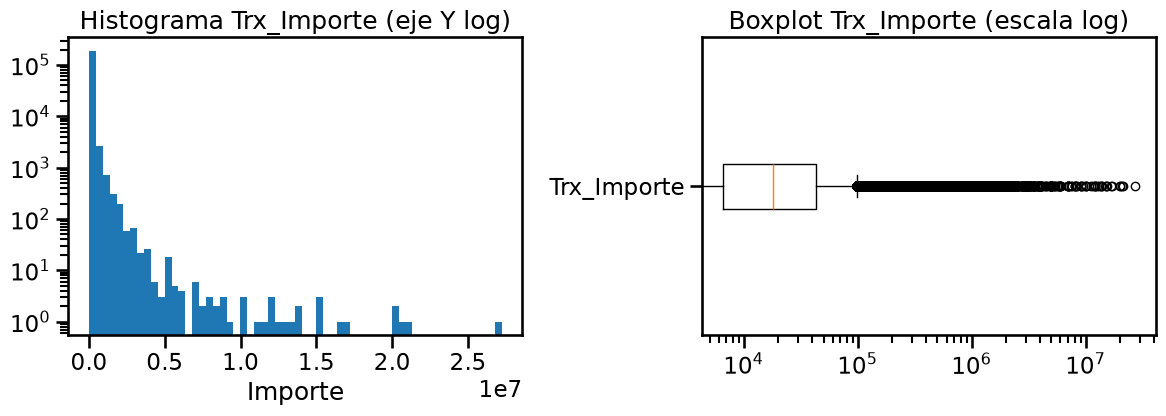

In [19]:
# Visualización de Trx_Importe
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

# Histograma de Trx_Importe en escala log (eje Y)
axes[0].hist(df['Trx_Importe'], bins=60)
axes[0].set_yscale('log')
axes[0].set_title('Histograma Trx_Importe (eje Y log)')
axes[0].set_xlabel('Importe')

# Boxplot de importe en escala log
axes[1].boxplot(df['Trx_Importe'], vert=False, tick_labels=['Trx_Importe'])
axes[1].set_xscale('log')
axes[1].set_title('Boxplot Trx_Importe (escala log)')

plt.tight_layout()
plt.show()

A partir de las visualización se confirma lo obtenido en los datos estadísticos, la variable Trx_Importe tiene una asimétria a la izquierda con la presencia de valores extremos. Dado que el desvío estándar era elevado, se optó por una escala logaritmica para mejor comprensión de la gráfica.

C:\Users\Mauri\AppData\Local\Temp\ipykernel_2572\1419114956.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['Cliente_Edad'], vert=False, tick_labels=['Cliente_Edad'])


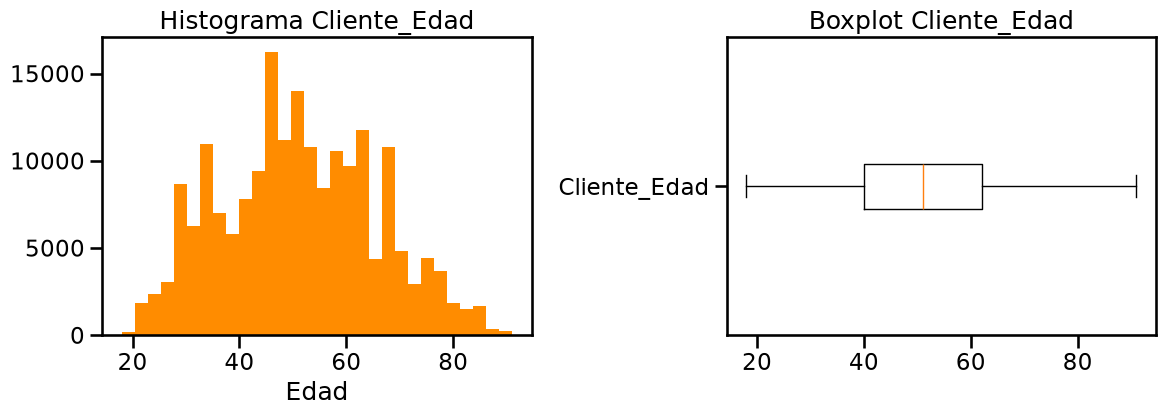

In [20]:
# Visualización de Cliente_Edad
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

# Histograma de edad
axes[0].hist(df['Cliente_Edad'], bins=30, color='darkorange')
axes[0].set_title('Histograma Cliente_Edad')
axes[0].set_xlabel('Edad')

# Boxplot de edad
axes[1].boxplot(df['Cliente_Edad'], vert=False, tick_labels=['Cliente_Edad'])
axes[1].set_title('Boxplot Cliente_Edad')

plt.tight_layout()
plt.show()

La variable edad presenta una distribución bastante simétrica, sin presencia de outliers.

### Estadístico Variables Categóricas

In [21]:
cat_cols = ['Cliente_Sexo','Cliente_EstadoCivil','Cliente_Segmento','Cliente_ActivoPlataforma',
            'Cuenta_Producto','Movimiento_Tipo','Trx_TipoTerminal','Trx_ModoIngreso',
            'Trx_EsChip','Trx_Estado','Trx_Moneda','Es_Fraude']

for col in cat_cols:
    print(f"--- {col} ({df[col].nunique()} categorías) ---")
    print(df[col].value_counts(dropna=False))
    print(f"Moda: {df[col].mode()[0]}  |  % de la moda: {df[col].value_counts(normalize=True, dropna=False).iloc[0]*100:.1f}%\n")

--- Cliente_Sexo (2 categorías) ---
Cliente_Sexo
FEMENINO     100423
MASCULINO     59599
NaN           32642
Name: count, dtype: int64
Moda: FEMENINO  |  % de la moda: 52.1%

--- Cliente_EstadoCivil (5 categorías) ---
Cliente_EstadoCivil
SOLTERO/A       124488
NaN              32642
CASADO/A         19307
VIUDO/A           8573
DIVORCIADO/A      7339
CONVIVIENTE        315
Name: count, dtype: int64
Moda: SOLTERO/A  |  % de la moda: 64.6%

--- Cliente_Segmento (8 categorías) ---
Cliente_Segmento
S6     53628
S4     38985
NaN    32642
S2     28306
S5     19284
S1     17652
S7      1189
S3       867
S8       111
Name: count, dtype: int64
Moda: S6  |  % de la moda: 27.8%

--- Cliente_ActivoPlataforma (2 categorías) ---
Cliente_ActivoPlataforma
Si    183469
No      9195
Name: count, dtype: int64
Moda: Si  |  % de la moda: 95.2%

--- Cuenta_Producto (2 categorías) ---
Cuenta_Producto
CajaAhorro         192539
CuentaCorriente       125
Name: count, dtype: int64
Moda: CajaAhorro  |  % de la mo

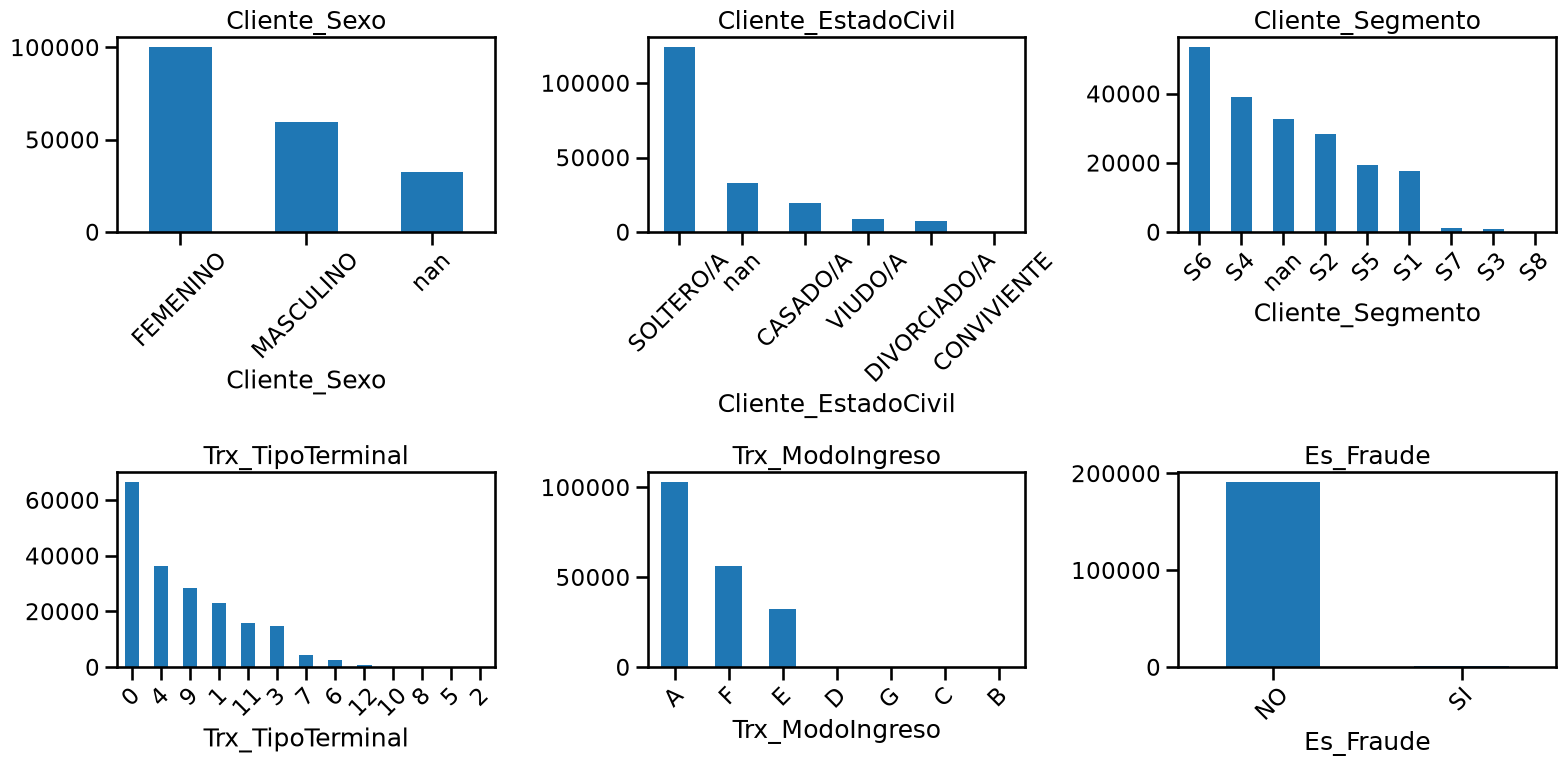

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16,8))
cols_graficar = ['Cliente_Sexo','Cliente_EstadoCivil','Cliente_Segmento',
                  'Trx_TipoTerminal','Trx_ModoIngreso','Es_Fraude']

for ax, col in zip(axes.flat, cols_graficar):
    df[col].value_counts(dropna=False).plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

El análisis estadístico nos permite identificar que la mayor frecuencia de transacciones corresponden a:
- Mujeres
- Soltera/os
- Corresponden a clientes del segmento S4 (Publico General), S6 (Sueldo Convenio Adm Publica)
- Se frecuenta el uso de canales de cajeros y homebanking, la terminal 0 (Transaccion realizada en Red de la Competencia) y 4 8Uso de tótems o terminales de autoservicio que están dentro de las sucursales bancarias) sobre el resto.
- El modo de ingreso es A (Terminal NO EMV )
- No es fraude.


## Limpieza y preparación de los datos

Dado que nuestro dataset tiene transacciondes clientes duplicados, puede deberse a un error en la carga de las mismas, vamos a proceder a eliminar dichas transacciones que figuran dos veces.
Con respecto a los datos nulos, se ha detectado su presencia en varias variables por lo cual se analizará cada caso y se tomará las decisiones para su tratamiento que se consideren optimas.
De mismo modo se trabajará con los outliers.
Comenzaremos por cambiar la variable Target de object a tipo numérica


In [23]:
# Conversión de la variable fraude
if df['Es_Fraude'].dtype == 'object':
    df['Es_Fraude'] = df['Es_Fraude'].map({'NO': 0, 'SI': 1})

print(df['Es_Fraude'].dtype)
print(df['Es_Fraude'].unique())

int64
[0 1]


De este modo se define

 0: no es fraude

 1 : si es fraude

In [24]:
# Guardamos referencia antes de eliminar
filas_antes = len(df)
fraude_antes = (df['Es_Fraude'] == 1).sum()

# Verificación de seguridad: confirmar que ningún duplicado es fraude antes de eliminar
dup_fraude = df[df.duplicated(keep=False)]['Es_Fraude'].value_counts()
print("Distribución de Es_Fraude entre las filas duplicadas:")
print(dup_fraude)

# Eliminemos transacciones duplicadas
df = df.drop_duplicates().reset_index(drop=True)

filas_despues = len(df)
fraude_despues = (df['Es_Fraude'] == 1).sum()

print(f"\nFilas antes: {filas_antes} | Filas después: {filas_despues} | Eliminadas: {filas_antes - filas_despues}")
print(f"Fraude antes: {fraude_antes} | Fraude después: {fraude_despues}")

Distribución de Es_Fraude entre las filas duplicadas:
Es_Fraude
0    296
Name: count, dtype: int64



Filas antes: 192664 | Filas después: 192516 | Eliminadas: 148
Fraude antes: 1196 | Fraude después: 1196


Se realizó la eliminación de duplicados, reduciendo el dataset en 148 filas (un 0,08% del total) sin afectar en absoluto a la variable objetivo, que es lo más importante de verificar antes de borrar cualquier dato en un problema con clases tan desbalanceadas como este.

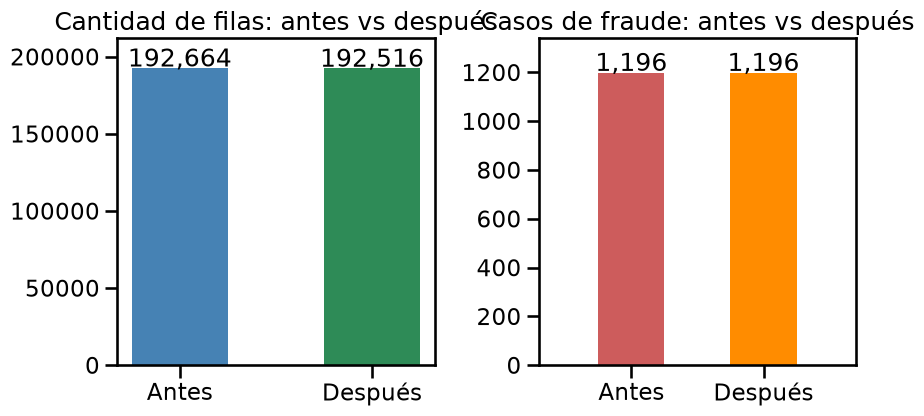

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(9,4.5))

axes[0].bar(['Antes','Después'], [filas_antes, filas_despues], color=['steelblue','seagreen'], width=0.5)
axes[0].set_title('Cantidad de filas: antes vs después')
axes[0].set_ylim(0, max(filas_antes, filas_despues) * 1.1)
for i,v in enumerate([filas_antes, filas_despues]):
    axes[0].text(i, v+1000, f"{v:,}", ha='center')

axes[1].bar(['Antes','Después'], [fraude_antes, fraude_despues], color=['indianred','darkorange'], width=0.5)
axes[1].set_title('Casos de fraude: antes vs después')
axes[1].set_xlim(-0.7, 1.7)
axes[1].set_ylim(0, max(fraude_antes, fraude_despues) * 1.12)
for i,v in enumerate([fraude_antes, fraude_despues]):
    axes[1].text(i, v+10, f"{v:,}", ha='center')

plt.tight_layout()
plt.show()

In [26]:
# Constatamos la existencia de valores nulos
nulos = df.isna().sum()
nulos_pct = (nulos/len(df)*100).round(2)
pd.DataFrame({'nulos':nulos,'%':nulos_pct})[nulos>0]

,nulos,%
Cliente_Sexo,32622,16.950000
Cliente_EstadoCivil,32622,16.950000
Cliente_Segmento,32622,16.950000
Trx_CiudadTerminal,5721,2.970000


**Trx_CiudadTerminal, Cliente_Sexo, Cliente_EstadoCivil y Cliente_Segmento** son las variables con datos faltantes, como habiamos detectado anteriormente.

**Cliente_Sexo, Cliente_EstadoCivil y Cliente_Segmento**, con casi un 17%,
tienen exactamente la misma cantidad de nulos (32.642). Esto puede sugerir que son los mismos clientes que no tienen esos tres datos completos.

**Trx_CiudadTerminal** probablemente corresponde a transacciones sin geolocalización de terminal: home banking, débitos automáticos, cajeros de redes que no informan ciudad.

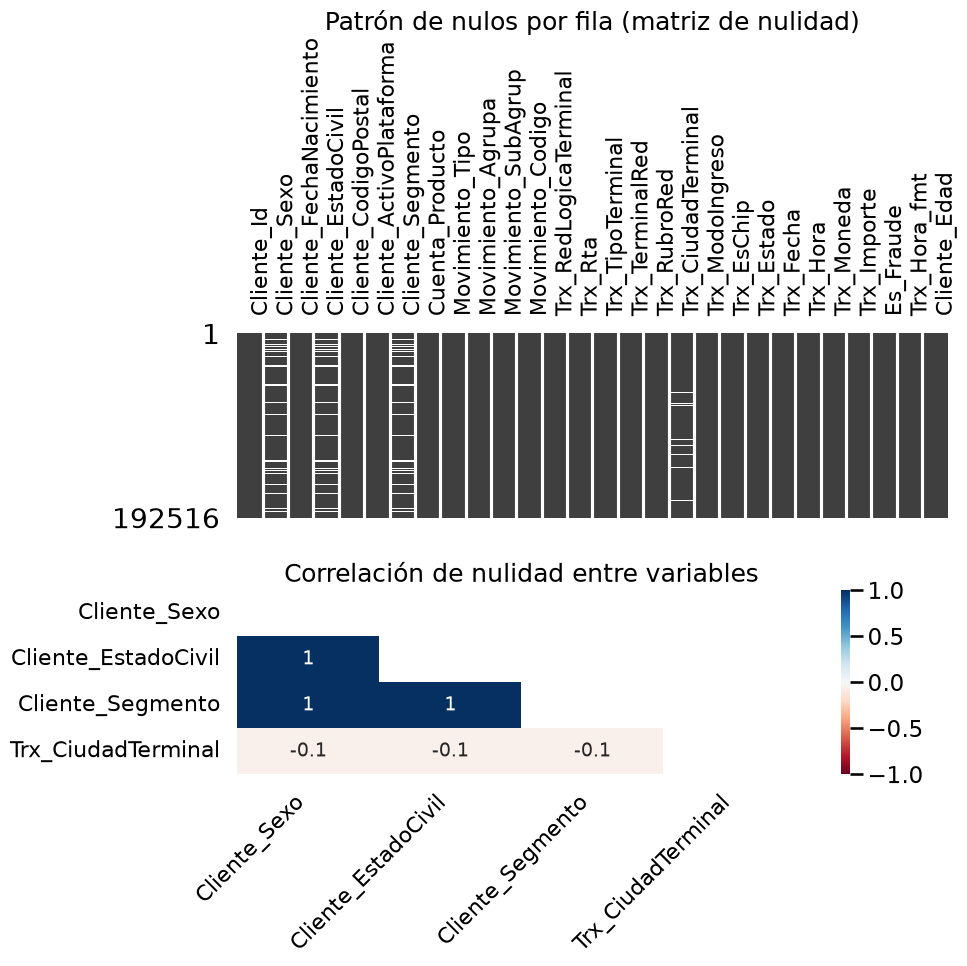

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
msno.matrix(df, ax=axes[0], sparkline=False)
axes[0].set_title('Patrón de nulos por fila (matriz de nulidad)')
axes[0].tick_params(axis='x', labelrotation=90)
axes[1].tick_params(axis='x', labelrotation=90)
msno.heatmap(df, ax=axes[1])
axes[1].set_title('Correlación de nulidad entre variables')
plt.tight_layout()
plt.show()

El heatmap de nulidad confirma visualmente lo que veníamos sospechando: `Cliente_Sexo`, `Cliente_EstadoCivil` y `Cliente_Segmento` tienen una correlación de nulidad de **1.0 entre sí** (siempre faltan exactamente en las mismas filas), mientras que `Trx_CiudadTerminal` tiene una correlación de nulidad cercana a **0 (~-0.1)** respecto de las otras tres. Esto respalda la hipótesis de que son **dos mecanismos de nulos completamente independientes**: uno ligado a la sincronización de datos maestros del cliente, y otro estructural del canal digital (Home Banking) que no tiene terminal física asociada. La matriz de la izquierda también deja ver que los huecos de las primeras columnas (datos del cliente) aparecen dispersos a lo largo de todo el dataset, no concentrados en un bloque de filas — otro indicio de que no es un problema de un lote o período puntual, sino de proceso.

In [28]:
#veamos si los datos faltantes corresponden a los mismos clientes
mismos_clientes = df[df['Cliente_Sexo'].isnull() & df['Cliente_EstadoCivil'].isnull() & df['Cliente_Segmento'].isnull()]
print(f"Filas con los 3 campos nulos simultáneamente: {len(mismos_clientes)}")

Filas con los 3 campos nulos simultáneamente: 32622


Confirma que los datos faltantes corresponden a los mismos clientes.
Dado que hay transacciones donde los clientes tienen el legajo completo y en otras no, utilizaremos la informacion del legajo completo para tratar los datos nulos.

In [29]:
clientes_con_nulo = df[df['Cliente_Sexo'].isna()]['Cliente_Id'].unique()
sub = df[df['Cliente_Id'].isin(clientes_con_nulo)]
recuperables = sub.groupby('Cliente_Id')['Cliente_Sexo'].apply(lambda x: x.notna().any())

print("Clientes con nulo:", len(clientes_con_nulo))
print("Recuperables (tienen el dato en otra fila):", recuperables.sum())
print("Irrecuperables (nulo en TODAS sus filas):", (~recuperables).sum())

Clientes con nulo: 670
Recuperables (tienen el dato en otra fila): 670
Irrecuperables (nulo en TODAS sus filas): 0


In [30]:
cols_legajo = ['Cliente_Sexo', 'Cliente_EstadoCivil', 'Cliente_Segmento']

for col in cols_legajo:
    df[col] = df.groupby('Cliente_Id')[col].transform(lambda x: x.ffill().bfill())

# Verificamos que ya no queden nulos
df[cols_legajo].isna().sum()

Cliente_Sexo           0
Cliente_EstadoCivil    0
Cliente_Segmento       0
dtype: int64

La función groupby('Cliente_Id') agrupa todas las transacciones de cada cliente, y ffill().bfill() "arrastra" el dato válido más cercano (hacia adelante y hacia atrás) dentro de ese grupo. Como confirmamos que cada cliente tiene el dato en al menos una fila, esto rellena el 100% de los nulos con información real de ese mismo cliente, no con un valor inventado.

In [31]:
# tabla de TipoTerminal
TipoTerminal = pd.read_excel(
    'Dr_Muestra.xlsx',
    sheet_name='Valores',
    skiprows=6,
    nrows=13
)

TipoTerminal.columns = ['Codigo', 'Descripcion', 'Agrupamiento']
TipoTerminal['Codigo'] = TipoTerminal['Codigo'].astype(int)

print(TipoTerminal)

    Codigo                                        Descripcion  \
0        0     Transaccion realizada en Red de la Competencia   
1        1  Transaccion realizada en cajero automático fís...   
2        2  Transaccion realizada en cajero automático fís...   
3        3  Operaciones hechas desde la web o app del banc...   
4        4  Uso de tótems o terminales de autoservicio que...   
5        5  Compras online con tarjeta Maestro procesadas ...   
6        6   Es cuando dejas tus datos guardados en una we...   
7        7  Similar al anterior, pero para transacciones q...   
8        8  Pagos de impuestos o servicios realizados dire...   
9        9  Operaciones realizadas a través de canales exc...   
10      10  Pagos realizados en terminales que no están en...   
11      11  Compras por internet realizadas específicament...   
12      12  Compras presenciales usando un mPOS (esos apar...   

                              Agrupamiento  
0        Canales de Cajeros y Home Banking  

In [32]:
# Nulos de la variable Trx_CiudadTerminal

sub = df[df['Trx_CiudadTerminal'].isna()]

# ¿Se puede recuperar por terminal (misma terminal en otra fila sí tiene ciudad)?
terminales_con_nulo = sub['Trx_TerminalRed'].unique()
check_term = df[df['Trx_TerminalRed'].isin(terminales_con_nulo)]
recuperable_terminal = check_term.groupby('Trx_TerminalRed')['Trx_CiudadTerminal'].apply(lambda x: x.notna().any())
print(f"Terminales recuperables: {recuperable_terminal.sum()} de {len(recuperable_terminal)}")

# Terminal en % — con nombres en lugar de códigos
tipo_terminal_pct = sub['Trx_TipoTerminal'].value_counts(normalize=True) * 100
tipo_terminal_pct_nombres = tipo_terminal_pct.rename(index=TipoTerminal.set_index('Codigo')['Descripcion'])
print(tipo_terminal_pct_nombres)

Terminales recuperables: 1 de 8
Trx_TipoTerminal
Operaciones hechas desde la web o app del banco donde se validó la identidad usando los datos de la tarjeta.                                                   91.539941
Operaciones realizadas a través de canales exclusivos de ese banco (puede ser su propia app o banca telefónica).                                                3.076385
Compras por internet realizadas específicamente con tarjeta de débito Mastercard.                                                                               2.831673
Uso de tótems o terminales de autoservicio que están dentro de las sucursales bancarias.                                                                        1.503234
Similar al anterior, pero para transacciones que no se clasifican estrictamente como una compra web estándar (pagos recurrentes administrativos o internos).    1.048768
Name: proportion, dtype: float64


La terminal que concentra el 91% de los datos nulos es la n°3, una causa probable es que no cuenta con geolocalización.
Dado que no podemos completar los datos nulos con información de los legajos de los clientes, ya que se trata de terminales de transacción como así tampoco imputar por la media u otro parámetro estadístico. Vamos a categorizarlos como "sin terminal"

In [33]:
print("Nulos antes:", df['Trx_CiudadTerminal'].isna().sum())

# Creamos la categoría
df['Trx_CiudadTerminal'] = df['Trx_CiudadTerminal'].fillna('SIN_TERMINAL')

#verificamos
print("Nulos después:", df['Trx_CiudadTerminal'].isna().sum())
print("Filas categorizadas como SIN_TERMINAL:", (df['Trx_CiudadTerminal']=='SIN_TERMINAL').sum())
print("Total de categorías distintas ahora:", df['Trx_CiudadTerminal'].nunique())

# Confirmamos que coincide con lo que esperábamos por tipo de terminal
df[df['Trx_CiudadTerminal']=='SIN_TERMINAL']['Trx_TipoTerminal'].value_counts()

Nulos antes: 5721
Nulos después: 0
Filas categorizadas como SIN_TERMINAL: 5721
Total de categorías distintas ahora: 3045


Trx_TipoTerminal
3     5237
9      176
11     162
4       86
7       60
Name: count, dtype: int64

Nuestro dataset quedó con cero datos nulos.



### Outliers

Tal como habíamos identificado anteriormente mediante el estadístico y las graficas de distribución, la variable Trx_Importe presenta valores extremos, los cuales vamos a acotar.

Sesgo positivo: La diferencia entre media y mediana indica que unos pocos valores muy grandes elevan el promedio.

Outliers: El máximo (27 millones) es desproporcionado respecto al resto. Conviene analizar dichos valores.


In [34]:
#Utilizamos cuartiles para determinar valores atípicos

Q1 = df['Trx_Importe'].quantile(.25)
Q3 = df['Trx_Importe'].quantile(.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5*IQR
lim_sup = Q3 + 1.5*IQR

df['Es_Outlier_Importe'] = ((df['Trx_Importe'] < lim_inf) | (df['Trx_Importe'] > lim_sup)).astype(int)

print(f"Límite inferior: {lim_inf:,.0f}")
print(f"Límite superior: {lim_sup:,.0f}")
print(f"Cantidad de outliers: {df['Es_Outlier_Importe'].sum():,} ({df['Es_Outlier_Importe'].mean()*100:.2f}%)")

Límite inferior: -48,250
Límite superior: 97,750
Cantidad de outliers: 23,319 (12.11%)


Aplicando el método IQR (Q1 - 1.5×IQR / Q3 + 1.5×IQR), se identificaron 23319
outliers (12.11% del dataset) en la variable Trx_Importe. El límite inferior
resultó negativo, lo cual es esperable dado que la variable no puede
tomar valores negativos y la distribución presenta asimetría hacia la derecha;
en consecuencia, todos los outliers detectados corresponden a montos
inusualmente altos.

Se analiza la relación entre estos outliers y la variable objetivo Es_Fraude
para determinar el tratamiento más adecuado.

In [35]:
tabla = pd.crosstab(df['Es_Outlier_Importe'], df['Es_Fraude'], normalize='index')*100
tabla.index = ['No outlier', 'Outlier']
tabla

Es_Fraude,0,1
No outlier,99.405427,0.594573
Outlier,99.185214,0.814786


El 99% de los datos outliers corresponden a no fraude. Pero hay casi un 1% que corresponde a fraude.

C:\Users\Mauri\AppData\Local\Temp\ipykernel_2572\2015033423.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(df['Trx_Importe'], vert=False, tick_labels=['Trx_Importe'])


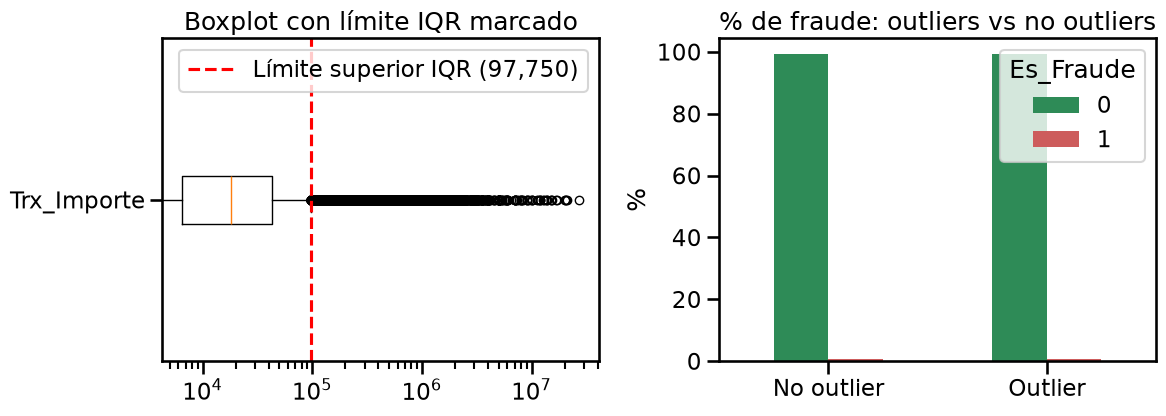

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

axes[0].boxplot(df['Trx_Importe'], vert=False, tick_labels=['Trx_Importe'])
axes[0].set_xscale('log')
axes[0].axvline(lim_sup, color='red', linestyle='--', label=f'Límite superior IQR ({lim_sup:,.0f})')
axes[0].set_title('Boxplot con límite IQR marcado')
axes[0].legend()

tabla.plot(kind='bar', ax=axes[1], color=['seagreen','indianred'])
axes[1].set_title('% de fraude: outliers vs no outliers')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Se observa que la tasa de fraude entre las transacciones identificadas como outliers  es aproximadamente superior a la tasa de fraude en transacciones normales. Esta relación sugiere que el monto atípico de una transacción aporta información relevante para la detección de fraude. Por este motivo, se decide no eliminar ni transformar los outliers en esta etapa, sino conservarlos y generar una variable indicadora (Es_Outlier_Importe).

In [37]:
# Cantidad y porcentaje de outliers
n_outliers = df['Es_Outlier_Importe'].sum()
pct_outliers = (n_outliers / len(df)) * 100

print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")
print(f"Cantidad de outliers: {n_outliers}")
print(f"Porcentaje de outliers: {pct_outliers:.2f}%")

display(tabla)

# Cálculo del incremento relativo
tasa_no_outlier = tabla.loc['No outlier', 1]
tasa_outlier = tabla.loc['Outlier', 1]
incremento_relativo = ((tasa_outlier / tasa_no_outlier) - 1) * 100

print(f"La tasa de fraude en outliers es {incremento_relativo:.1f}% "
      f"superior a la tasa en no-outliers")

Límite inferior: -48250.00
Límite superior: 97750.00
Cantidad de outliers: 23319
Porcentaje de outliers: 12.11%


Es_Fraude,0,1
No outlier,99.405427,0.594573
Outlier,99.185214,0.814786


La tasa de fraude en outliers es 37.0% superior a la tasa en no-outliers


## 3.	Análisis y Visualización de los datos

Para un buena predicción/segmentación es necesario realizar un buen análisis descriptivo, exploración de los datos considerando su tipo y valores definidos y tener acabado conocimiento de que representa cada uno de ellos.

Para los datos numéricos realizar una breve descripción de los mismos, analizando sus medias, percentiles, outliers.
Mientras que para las variables categóricas realizar un análisis de transaccionalidad vrs Rubro, Estado Civil, Sexo, Edad, Activolataforma, etc. Realizar un análisis de variabilidad de la transaccionalidad respecto de estas variables para cada Clase (Es Fraude / No es Fraude)y otras más que puedan considerar de utilidad para el entendimiento del comportamiento del cliente, dado que esto nos ayudara en nuestro modelo de deteccion de anomalias y asi mitigar el fraude al detectarlo con atelacion.

Algunas de las preguntas que nos podríamos realizar son las siguientes:

¿A qué fecha son los datos? ¿Fue correcto la selección de este periodo para el análisis? ¿Contamos con suficientes datos para llevar a cabo esa prediccion?

¿Hay datos nulos? ¿Hay OutLiers? Identificar valores atipicos y nulos.

¿Hay datos duplicados? ¿Cuantos clientes tenemos en nuestro dataset?

¿Como es la distribucion del dato Trx_Importe? ¿Es necesario considerar por moneda (pesos/dolar)? De un comentario al respecto.

¿Al dato Trx_RubroRed, ¿cómo lo consideramos? Discreto o continuo? Grafique su distribucion y de breve comentario.

¿Existe algún tipo de relación entre Rubro_Red, Trx_terminalRed , Trx_CiudadTerminal?

¿Con que frecuencia realiza las compras? Dia de la semana, dia del mes. Ejemplo, compra todos los lunes, compra todos los 1 de cada mes.

¿Que tiempo transcurre entre transacciones?

¿Que rubros son los mas frecuentes?

¿Que rubros son los que mas importe gastan los clientes?

¿Cuales son los horarios de compras habituales de los clientes?

¿Qué tipo de movimiento se realiza más? Transferencia, compra, pago de impuesto, etc.

¿El cliente estuvo presente en la compra?

¿Cuál es el importe promedio gastado para ciertos días en ciertos rubros de comercio?

¿Como se encuentran las clases Fraude / No Fraude, estan balanceadas? (¿Hay mas transacciones No Fraudulentas que Fraudulentas? o viceversa)
Comparar el comportamiento de las transacciones Fraudulentas vrs No Fraudulentas, se puede comparar:
    Hora del dia
    Dia de la semana
    Frecuencia entre que ocurren
    Tipo de movimiento (Compra en pesos o compra extranjera)
    Tipo Terminal utilizada , IdTerminal utilizada
    Ciudad de la transaccion
    Rubro de Compra
    Hacer un comparativo de Rubro , Ciudad
    Tiempo transcurrido entre transacciones
    Cuales son los rubros mas populares

Basándose en los análisis anteriores, realice una matriz de correlacion entre las variables y la variable target.

Puede ya definir cuales serán las variables mas interesantes que contribuirán al modelo.


### Contexto Temporal

In [38]:
# ===================
# Contexto Temporal
# ===================

#1.Fecha
fecha_min = df['Trx_Fecha'].min()
fecha_max = df['Trx_Fecha'].max()
dias_cubiertos = (fecha_max - fecha_min).days

print("=== 1. Rango temporal del dataset ===")
print(f"Fecha mínima: {fecha_min.strftime('%d/%m/%Y')}")
print(f"Fecha máxima: {fecha_max.strftime('%d/%m/%Y')}")
print(f"Días cubiertos: {dias_cubiertos} ({dias_cubiertos/30:.1f} meses aprox.)")

# Distribución de transacciones por mes
trx_por_mes = df['Trx_Fecha'].dt.to_period('M').value_counts().sort_index()
print("\nTransacciones por mes:")
print(trx_por_mes)

# 2. Volumen de datos vs. desbalance de clases
n_total = len(df)
n_fraude = (df['Es_Fraude'] == 1).sum()
n_clientes = df['Cliente_Id'].nunique()

print("\n=== 2. Volumen de datos ===")
print(f"Total de transacciones: {n_total:,}")
print(f"Total de clientes únicos: {n_clientes}")
print(f"Transacciones fraudulentas: {n_fraude} ({n_fraude/n_total*100:.2f}%)")
print(f"Promedio de transacciones por cliente: {n_total/n_clientes:.1f}")
print(f"Promedio de casos de fraude por cliente: {n_fraude/n_clientes:.2f}")

# 3. Resumen de calidad del dato (consolidado de limpieza previa)
print("\n=== 3. Resumen de calidad del dato ===")
print(f"Duplicados eliminados: 148 filas (0.08% del dataset original)")
print(f"Nulos en Cliente_Sexo/EstadoCivil/Segmento: 670 clientes afectados")
print(f"Nulos en Trx_CiudadTerminal: {(df['Trx_CiudadTerminal']=='SIN_TERMINAL').sum()} filas categorizadas como 'SIN_TERMINAL'")
print(f"Outliers en Trx_Importe (IQR): {df['Es_Outlier_Importe'].sum()} filas ({df['Es_Outlier_Importe'].mean()*100:.2f}%)")

# Verificación de nulos remanentes (control final)
print("\nNulos remanentes por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

=== 1. Rango temporal del dataset ===
Fecha mínima: 01/01/2025
Fecha máxima: 31/12/2025
Días cubiertos: 364 (12.1 meses aprox.)

Transacciones por mes:
Trx_Fecha
2025-01    15854
2025-02    14466
2025-03    16034
2025-04    15418
2025-05    15854
2025-06    16232
2025-07    16620
2025-08    17204
2025-09    16426
2025-10    17163
2025-11    17556
2025-12    13689
Freq: M, Name: count, dtype: int64

=== 2. Volumen de datos ===
Total de transacciones: 192,516
Total de clientes únicos: 716
Transacciones fraudulentas: 1196 (0.62%)
Promedio de transacciones por cliente: 268.9
Promedio de casos de fraude por cliente: 1.67

=== 3. Resumen de calidad del dato ===
Duplicados eliminados: 148 filas (0.08% del dataset original)
Nulos en Cliente_Sexo/EstadoCivil/Segmento: 670 clientes afectados
Nulos en Trx_CiudadTerminal: 5721 filas categorizadas como 'SIN_TERMINAL'
Outliers en Trx_Importe (IQR): 23319 filas (12.11%)

Nulos remanentes por columna:


Series([], dtype: int64)


**Datos**

El dataset cubre el año calendario completo 2025. La distribución mensual de transacciones es relativamente estable, oscilando entre ~13,700 y ~17,600 transacciones por mes. Se observa una disminución en diciembre que podría
responder a estacionalidad de fin de año o a un corte de datos levemente
anterior al 31/12. En general, contar con un ciclo anual
completo es adecuado para el análisis, ya que permite capturar posibles
patrones de comportamiento de los clientes.

**Cantidad de datos**

El dataset cuenta con 192,516 transacciones pertenecientes a 716 clientes, de las cuales 1,196 corresponden a fraude (0.62%). Si bien el volumen total de transacciones es considerable.

**Datos nulos**

No quedan nulos en el dataset: los nulos originales en variables
de cliente (Cliente_Sexo, Cliente_EstadoCivil, Cliente_Segmento — 670
clientes afectados) fueron recuperados vía Cliente_Id, y los nulos en
Trx_CiudadTerminal (5,721 filas) fueron categorizados como 'SIN_TERMINAL'.
Respecto a outliers, se identificaron 23,319 transacciones (12.11%) con
montos atípicamente altos en Trx_Importe mediante el método IQR, las cuales
se decidió conservar ya que presentan una tasa de fraude 37% superior al
resto  y marcar mediante la variable indicadora Es_Outlier_Importe.

**Clientes duplicados**

Se identificaron y eliminaron 148 filas exactamente duplicadas (0.08% del
dataset original, todas correspondientes a transacciones no fraudulentas).
El dataset final cuenta con 716 clientes únicos.

### Trx_Importe

Se analiza la distribución de la variable Trx_Importe y se evalúa si corresponde diferenciar el análisis según la moneda
de la transacción (Trx_Moneda).

In [39]:
print(df['Trx_Moneda'].dtype)
print(df['Trx_Moneda'].unique())

int64
[1 2]


La variable Trx_Moneda tiene dos categorías, que hacen referencia a dos tipos de monedas diferentes.
Por medio de la fuente de datos, sabemos que:

moneda 1:  Pesos

moneda 2: Dólares

In [40]:
# ============================================
#           Análisis de Trx_Importe
# ============================================

# 1. Estadísticos descriptivos
print("=== 1. Estadísticos descriptivos de Trx_Importe (general) ===")
print(df['Trx_Importe'].describe())

print("\nPercentiles adicionales:")
for p in [0.01, 0.05, 0.10, 0.90, 0.95, 0.99]:
    print(f"P{int(p*100)}: {df['Trx_Importe'].quantile(p):,.2f}")

# 2. Distribución de Trx_Moneda
print("\n=== 2. Distribución por moneda ===")
print(df['Trx_Moneda'].value_counts())
print(f"\n% pesos: {(df['Trx_Moneda']==1).mean()*100:.2f}%")
print(f"% dólares: {(df['Trx_Moneda']==2).mean()*100:.2f}%")

#  3. Trx_Importe segmentado por moneda
print("\n=== 3. Estadísticos de Trx_Importe por moneda ===")
print(df.groupby('Trx_Moneda')['Trx_Importe'].describe())

# 4. Tasa de fraude según moneda
tabla_moneda_fraude = pd.crosstab(
    df['Trx_Moneda'].map({1: 'Pesos', 2: 'Dólares'}),
    df['Es_Fraude'].map({0: 'NO', 1: 'SI'}),
    normalize='index'
) * 100

print("\n=== 4. Tasa de fraude según moneda ===")
print(tabla_moneda_fraude)


=== 1. Estadísticos descriptivos de Trx_Importe (general) ===
count     192516.000000
mean       60447.040358
std       258986.076324
min            0.000000
25%         6500.000000
50%        17971.345000
75%        43000.000000
max     27232927.760000
Name: Trx_Importe, dtype: float64

Percentiles adicionales:
P1: 3.18
P5: 1,200.00
P10: 2,516.50
P90: 100,871.00
P95: 217,000.00
P99: 763,501.00

=== 2. Distribución por moneda ===
Trx_Moneda
1    186539
2      5977
Name: count, dtype: int64

% pesos: 96.90%
% dólares: 3.10%

=== 3. Estadísticos de Trx_Importe por moneda ===
                   count         mean           std      min         25%  \
Trx_Moneda                                                                 
1          186539.000000 62383.120318 262872.996723 0.000000 7300.975000   
2            5977.000000    23.011640    140.567954 0.010000    2.990000   

                    50%          75%             max  
Trx_Moneda                                            
1    

La variable **Trx_Importe** presenta una distribución fuertemente asimétrica a la derecha, la media es de \$60.447 superando ampliamente a la mediana de \$17.971, y el valor máximo registrado, que supera los 27 millones, se encuentra muy alejado del percentil 99. Esta asimetría es consistente con lo observado en el análisis de outliers.

Se identificaron dos monedas en el dataset correspondiente la moneda 1: pesos y moneda 2: dólares, que representan el 96,90% y 3,10% de las transacciones
respectivamente. Ambas monedas operan en escalas  distintas:  La mediana de la moneda pesos es \$19,217 y la moneda dólares es \$6.50.

Se observa una diferencia  en la tasa de fraude según la moneda. Mientras que las transacciones en moneda en pesos presentan una tasa de fraude de 0,34%, las transacciones en moneda dólar presenta una tasa de fraude de 9,45%. Esto implica que, el dólar concentra una proporción alta de los casos de fraude
del dataset.

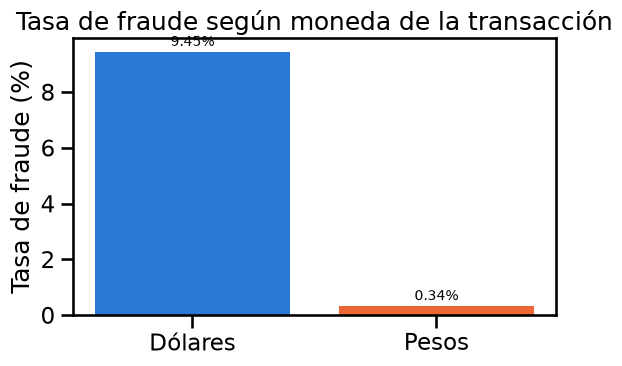

In [41]:
#5. Visualización: tasa de fraude por moneda
tasas = tabla_moneda_fraude['SI']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(tasas.index, tasas.values, color=['#2a78d6', '#eb6834'])
ax.set_ylabel('Tasa de fraude (%)')
ax.set_title('Tasa de fraude según moneda de la transacción')
for bar, val in zip(bars, tasas.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val:.2f}%',
             ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Trx_RubroRed

Es una variable discreta, ya que presenta el código del rubro del comercio donde se efectuo la compra. No expresa cantidades.
En este caso, realizaremos un merge, dado que el dataset transaccional contiene el código de rubro (Trx_RubroRed), pero no
su descripción, entonces mediante un merge con la tabla de referencia RubroRed (obtenida del excel Dr_Muestra.xlsx), se incorpora al dataset principal el nombre descriptivo de cada rubro, utilizando el código como clave común entre ambas tablas.

Trx_RubroRed = -1, representa transacciones sin rubro identificado.

In [42]:
# ==========================================================
# Distribución de Trx_RubroRed con nombres de comercio
# ==========================================================

#Descripcion de la tabla de Rubros
df_rubro = pd.read_excel('Dr_Muestra.xlsx', sheet_name='RubroRed')
print(df_rubro.head())

# 2. Merge con el dataset principal
df = df.merge(
    df_rubro[['Codigo', 'Descripcion']].rename(columns={'Codigo': 'Rubro_Codigo', 'Descripcion': 'Rubro_Descripcion'}),
    left_on='Trx_RubroRed',
    right_on='Rubro_Codigo',
    how='left'
).drop(columns=['Rubro_Codigo'])

# Para las transacciones donde Trx_RubroRed = -1 (no aplica), asignar etiqueta explícita
df['Rubro_Descripcion'] = df['Rubro_Descripcion'].fillna('SIN RUBRO / NO APLICA')

# 3. Distribución con nombres
distribucion_rubro = df['Rubro_Descripcion'].value_counts()

print(f"\nCantidad de categorías únicas (con nombre): {distribucion_rubro.shape[0]}")
print(f"\nTop 15 rubros más frecuentes:")
print(distribucion_rubro.head(15))



   Codigo                                        Descripcion  \
0     298   Servicios de producción de granos y agricultura.   
1     400   Servicios de logística y transporte de carga ...   
2     501  Servicios de arquitectura e ingeniería: Genera...   
3     511   Servicios de planificación y diseño de sistem...   
4     742                             Servicios veterinarios   

                     Categoría de Rubro  
0                  Agrícola / Agronomía  
1                            Transporte  
2  Servicios Profesionales y Educativos  
3  Servicios Profesionales y Educativos  
4                  Agrícola / Agronomía  

Cantidad de categorías únicas (con nombre): 256

Top 15 rubros más frecuentes:
Rubro_Descripcion
SIN RUBRO / NO APLICA                                                                                          103499
Tiendas de comestibles, supermercados                                                                           17213
Servicios profesionales: no c

In [43]:
print(df.columns.tolist())

['Cliente_Id', 'Cliente_Sexo', 'Cliente_FechaNacimiento', 'Cliente_EstadoCivil', 'Cliente_CodigoPostal', 'Cliente_ActivoPlataforma', 'Cliente_Segmento', 'Cuenta_Producto', 'Movimiento_Tipo', 'Movimiento_Agrupa', 'Movimiento_SubAgrup', 'Movimiento_Codigo', 'Trx_RedLogicaTerminal', 'Trx_Rta', 'Trx_TipoTerminal', 'Trx_TerminalRed', 'Trx_RubroRed', 'Trx_CiudadTerminal', 'Trx_ModoIngreso', 'Trx_EsChip', 'Trx_Estado', 'Trx_Fecha', 'Trx_Hora', 'Trx_Moneda', 'Trx_Importe', 'Es_Fraude', 'Trx_Hora_fmt', 'Cliente_Edad', 'Es_Outlier_Importe', 'Rubro_Descripcion']


C:\Users\Mauri\AppData\Local\Temp\ipykernel_2572\2794760693.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


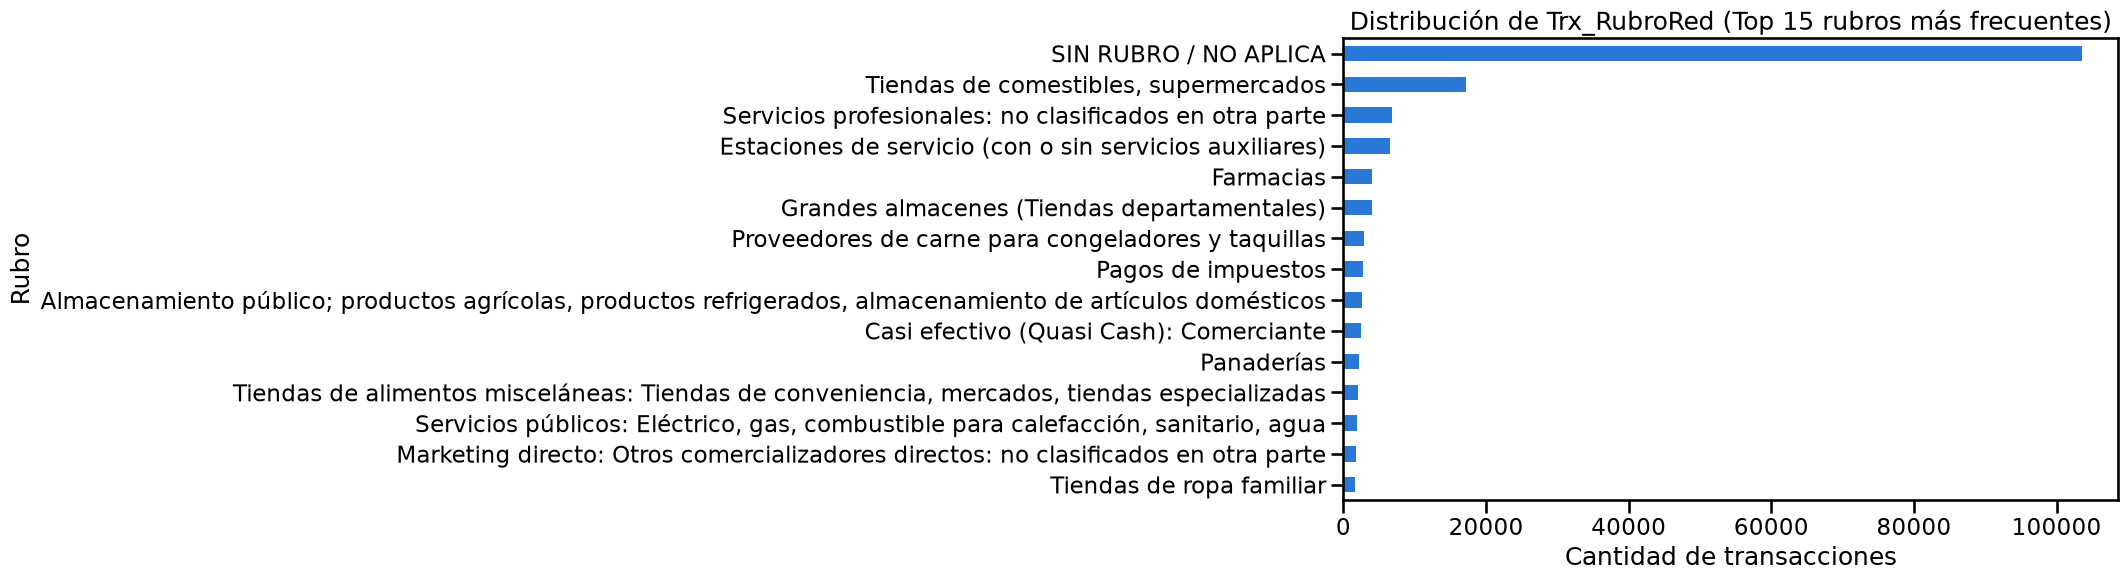

In [44]:
#  4. Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
distribucion_rubro.head(15).plot(kind='barh', ax=ax, color='#2a78d6')
ax.set_xlabel('Cantidad de transacciones')
ax.set_ylabel('Rubro')
ax.set_title('Distribución de Trx_RubroRed (Top 15 rubros más frecuentes)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

El rubro con mayor cantidad de transacciones no está identificado, dado que fue categorizado como SIN RUBRO.
Dato a tener en cuenta para nuestro futuro modelo.


Veamos si existe una relacion entre Trx_RubroRed, Trx_TerminalRed y Trx_CiudadTerminal.



In [45]:
# =====================================================================
#    Relación entre Trx_RubroRed, Trx_TerminalRed y Trx_CiudadTerminal
# =====================================================================

# 1. Relación RubroRed (-1 para no definidos) vs TerminalRed ('NO APLICA' Para transacciones que no son de Compra.)
tabla_rubro_terminal = pd.crosstab(
    df['Trx_RubroRed'] == -1,
    df['Trx_TerminalRed'] == 'NO APLICA'
)
tabla_rubro_terminal.index = ['RubroRed != -1', 'RubroRed == -1']
tabla_rubro_terminal.columns = ['TerminalRed != NO APLICA', 'TerminalRed == NO APLICA']

print("=== 1. RubroRed (no identificados) vs TerminalRed (transacciones que no son compra) ===")
print(tabla_rubro_terminal)

# Casos excepción: RubroRed = -1 pero SÍ hay terminal asignada
excepciones = df[(df['Trx_RubroRed'] == -1) & (df['Trx_TerminalRed'] != 'NO APLICA')]
print(f"\nCasos excepción (RubroRed=-1 con terminal identificada): {len(excepciones)}")

#  2. Cardinalidad: terminales por rubro y rubros por terminal
df_validos = df[df['Trx_RubroRed'] != -1]

terminales_por_rubro = df_validos.groupby('Trx_RubroRed')['Trx_TerminalRed'].nunique()
rubros_por_terminal = df_validos.groupby('Trx_TerminalRed')['Trx_RubroRed'].nunique()

print("\n=== 2. Cantidad de terminales distintas por rubro ===")
print(terminales_por_rubro.describe())

print("\n=== 3. Cantidad de rubros distintos por terminal ===")
print(rubros_por_terminal.describe())

#  3. Cardinalidad de ciudades -
print(f"\n=== 4. Ciudades únicas en Trx_CiudadTerminal: {df['Trx_CiudadTerminal'].nunique()} ===")
print(df['Trx_CiudadTerminal'].value_counts().head(10))

=== 1. RubroRed (no identificados) vs TerminalRed (transacciones que no son compra) ===
                TerminalRed != NO APLICA  TerminalRed == NO APLICA
RubroRed != -1                     89017                         0
RubroRed == -1                       216                    103283

Casos excepción (RubroRed=-1 con terminal identificada): 216

=== 2. Cantidad de terminales distintas por rubro ===
count    255.000000
mean      41.713725
std      123.884060
min        1.000000
25%        2.000000
50%        9.000000
75%       31.500000
max     1411.000000
Name: Trx_TerminalRed, dtype: float64

=== 3. Cantidad de rubros distintos por terminal ===
count   10148.000000
mean        1.048187
std         1.702277
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       124.000000
Name: Trx_RubroRed, dtype: float64

=== 4. Ciudades únicas en Trx_CiudadTerminal: 3045 ===
Trx_CiudadTerminal
0000000000000    57363
CORDOBA          26029
CAP.FEDERAL      1

Sí, existe una relación  entre Trx_RubroRed y Trx_TerminalRed ya que cuando Trx_TerminalRed = 'NO APLICA' (no corresponde a compra)  el rubro asociado es -1 (sin rubro identificado). Es decir, ambas condiciones representan transacciones sin comercio físico involucrado (transferencias, pagos, etc.).
Sin embargo, existen 216 casos donde Trx_RubroRed = -1 pero sí hay una terminal válida identificada, los cuales se pueden revisar.

A nivel de cardinalidad, cada terminal está asociada mayormente a un único
rubro (mediana = 1 rubro por terminal), lo cual es coherente con la lógica
de negocio: una terminal física de cobro suele pertenecer a un comercio de
un rubro específico. En cambio, la cantidad de terminales por rubro varía
ampliamente (mediana de 9, máximo de 1,411), reflejando que ciertos rubros
(por ejemplo, los más frecuentes como supermercados) cuentan con una red de
terminales mucho más extensa que rubros de nicho.

Respecto a Trx_CiudadTerminal, se identificaron 3.044 valores únicos, esto se debe a que hay ciudades que pertenecen a la misma provincia.

In [46]:
# ==========================================================
#  Frecuencia de transacciones: día de semana y día del mes
# ==========================================================

# 1. Distribución general por día de la semana
dias_es = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df['Dia_Semana'] = df['Trx_Fecha'].dt.day_name().map(dias_es)
df['Dia_Mes'] = df['Trx_Fecha'].dt.day

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
dist_dia_semana = df['Dia_Semana'].value_counts().reindex(orden_dias)

print("=== 1. Distribución general por día de la semana ===")
print(dist_dia_semana)

#  2. Distribución general por día del mes
dist_dia_mes = df['Dia_Mes'].value_counts().sort_index()
print("\n=== 2. Distribución general por día del mes ===")
print(dist_dia_mes)


=== 1. Distribución general por día de la semana ===
Dia_Semana
Lunes        27427
Martes       28628
Miércoles    29075
Jueves       30400
Viernes      32450
Sábado       27540
Domingo      16996
Name: count, dtype: int64

=== 2. Distribución general por día del mes ===
Dia_Mes
1     7733
2     7378
3     7740
4     7751
5     7641
6     7412
7     7342
8     7032
9     6591
10    7669
11    6499
12    6307
13    6158
14    6342
15    6337
16    5610
17    5994
18    6047
19    5687
20    5616
21    5665
22    5698
23    4938
24    4952
25    5010
26    5163
27    5251
28    5721
29    5526
30    5965
31    3741
Name: count, dtype: int64


El día con mayor cantidad de transacciones es el día viernes, seguido del jueves y el miércoles correspondiente a los primeros diez días del mes.

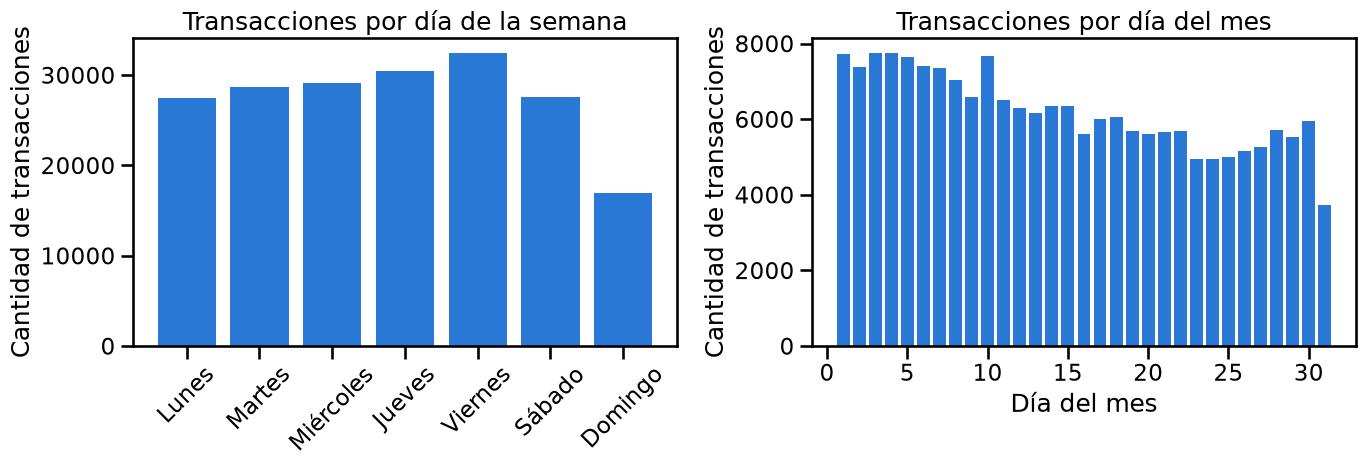

In [47]:
#  3. Visualización: distribución general por día de semana ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dist_dia_semana.index, dist_dia_semana.values, color='#2a78d6')
axes[0].set_title('Transacciones por día de la semana')
axes[0].set_ylabel('Cantidad de transacciones')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(dist_dia_mes.index, dist_dia_mes.values, color='#2a78d6')
axes[1].set_title('Transacciones por día del mes')
axes[1].set_xlabel('Día del mes')
axes[1].set_ylabel('Cantidad de transacciones')

plt.tight_layout()
plt.show()

### ¿Qué tiempo transcurre entre transacciones?

 Para calcular el tiempo que transcurre entre transacciones debemos poder restar una operación de la siguiente. Para ello, la fecha y hora de cada transacciones deben estar expresadas como un solo valor, ya que no podemos restar una fecha y una hora por separado porque son dos tipos de datos distintos en Python/pandas (date vs time), y no hay una operación matemática definida entre "una fecha" y "una hora" sueltas. Por eso vamos a combinarlas en un único objeto (datetime) para que la resta tenga sentido.
 Se calcula, para cada cliente, el tiempo transcurrido entre transacciones
consecutivas, combinando Trx_Fecha y Trx_Hora en un timestamp completo. Esto
permite entender la frecuencia temporal real del comportamiento transaccional
de cada cliente (por ejemplo, si opera varias veces por día o de forma más
esporádica).

 Un timestamp es simplemente una fecha y una hora juntas en un solo valor.


In [48]:
# ============================================
#    Tiempo transcurrido entre transacciones
# ============================================

# 1. Combinar Trx_Fecha (fecha) y Trx_Hora_fmt (hora) en un timestamp único
df['Trx_Timestamp'] = pd.to_datetime(
    df['Trx_Fecha'].dt.strftime('%Y-%m-%d') + ' ' + df['Trx_Hora_fmt'].astype(str)
)

print("Timestamps nulos:", df['Trx_Timestamp'].isna().sum())

#  2. Ordenar por cliente y timestamp, calcular diferencia entre transacciones consecutivas
df = df.sort_values(['Cliente_Id', 'Trx_Timestamp'])
df['Tiempo_Entre_Trx_Horas'] = df.groupby('Cliente_Id')['Trx_Timestamp'].diff().dt.total_seconds() / 3600

#  3. Estadísticos generales (excluyendo la primera transacción de cada cliente, que da NaN)
print("\n=== Estadísticos de tiempo entre transacciones (en horas) ===")
print(df['Tiempo_Entre_Trx_Horas'].describe())

print("\nEn días:")
print((df['Tiempo_Entre_Trx_Horas'] / 24).describe())

# Percentiles adicionales, útiles para ver la mediana real (menos afectada por outliers)
print("\nPercentiles (horas):")
for p in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"P{int(p*100)}: {df['Tiempo_Entre_Trx_Horas'].quantile(p):.2f} hs")



Timestamps nulos: 0

=== Estadísticos de tiempo entre transacciones (en horas) ===
count   191800.000000
mean        29.135435
std         91.224188
min          0.000000
25%          0.469444
50%          6.846806
75%         24.681181
max       7110.018333
Name: Tiempo_Entre_Trx_Horas, dtype: float64

En días:
count   191800.000000
mean         1.213976
std          3.801008
min          0.000000
25%          0.019560
50%          0.285284
75%          1.028383
max        296.250764
Name: Tiempo_Entre_Trx_Horas, dtype: float64

Percentiles (horas):
P10: 0.03 hs
P25: 0.47 hs
P50: 6.85 hs
P75: 24.68 hs
P90: 66.74 hs
P95: 116.40 hs
P99: 369.16 hs



El tiempo transcurrido entre transacciones consecutivas por
cliente presenta una distribución fuertemente asimétrica ya que la mediana 6.85 horas es menor al valor promedio 29.1 horas.

El 25% de las transacciones ocurre dentro de la media hora posterior a la
anterior (P25 = 0.47 hs = 27.6 min), y el 75% dentro de aproximadamente un día
(P75 = 24.68 hs). Un 10% (P10 = 0.03 hs = 1.8 min) de las transacciones ocurre en un lapso menor a 2 minutos respecto de la anterior, lo cual podría corresponder a operaciones con reintentos de pago, compras múltiples en un mismo lugar, etc.). De todos modos, es conveniente una revisión en su relación con el fraude.
Asimismo, existen clientes con  intervalos excepcionalmente largos entre operaciones, hasta 296 días en el caso máximo.

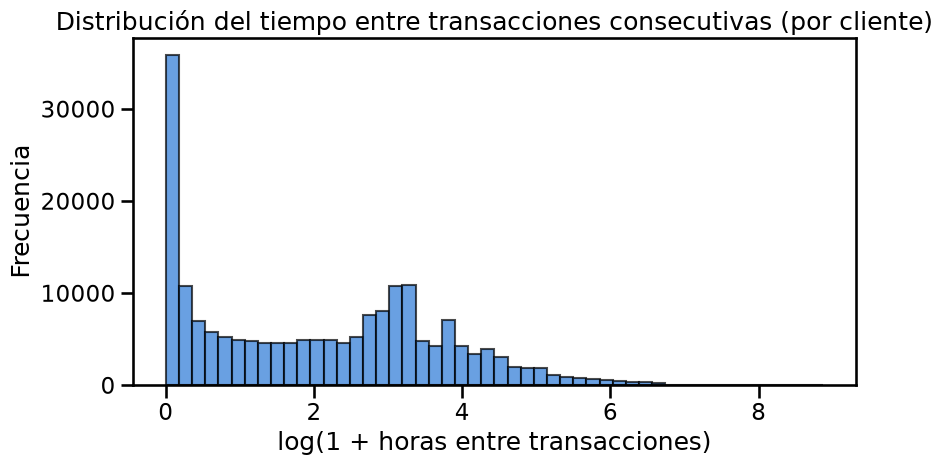

In [49]:
#  4. Visualización: distribución del tiempo entre transacciones ---
fig, ax = plt.subplots(figsize=(9, 5))
datos_validos = df['Tiempo_Entre_Trx_Horas'].dropna()
ax.hist(np.log1p(datos_validos), bins=50, color='#2a78d6', edgecolor='black', alpha=0.7)
ax.set_xlabel('log(1 + horas entre transacciones)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del tiempo entre transacciones consecutivas (por cliente)')
plt.tight_layout()
plt.show()

Transacciones consecutivas con distribución a la izquierda, debido a la existencia de transacciones consecutivas realizadas en brevedad de tiempo.

### ¿Cuáles son los horarios de compras habituales de los clientes?

Se analiza la distribución horaria de las transacciones, para identificar franjas horarias de mayor actividad transaccional.

In [50]:
# ============================================
#        Horarios habituales de compra
# ============================================

# 1. Extraer la hora del día desde Trx_Hora_fmt
df['Hora_Dia'] = df['Trx_Hora_fmt'].apply(lambda x: x.hour)

# 2. Distribución general por hora del día (0 a 23)
dist_hora = df['Hora_Dia'].value_counts().sort_index()

print("=== Distribución de transacciones por hora del día ===")
print(dist_hora)

# 3. Identificar las horas "pico" (top 5)
top_horas = dist_hora.sort_values(ascending=False).head(5)
print("\n=== Top 5 horas con más transacciones ===")
print(top_horas)

#  4. Franjas horarias agrupadas (madrugada, mañana, mediodía, tarde, noche)
def franja_horaria(h):
    if 0 <= h < 6:
        return 'Madrugada (00-06)'
    elif 6 <= h < 12:
        return 'Mañana (06-12)'
    elif 12 <= h < 15:
      return 'Mediodía (12-15)'
    elif 15 <= h < 19:
        return 'Tarde (15-19)'
    else:
        return 'Noche (19-24)'

df['Franja_Horaria'] = df['Hora_Dia'].apply(franja_horaria)
dist_franja = df['Franja_Horaria'].value_counts()

print("\n=== Distribución por franja horaria ===")
print(dist_franja)
print("\nEn porcentaje:")
print((dist_franja / len(df) * 100).round(2))



=== Distribución de transacciones por hora del día ===
Hora_Dia
0      2995
1      1940
2      1215
3       784
4       769
5       862
6      1782
7      3219
8      6552
9     11534
10    16078
11    18854
12    17338
13    11728
14     8870
15     7597
16     8188
17    11408
18    13569
19    14081
20    13427
21     9259
22     6036
23     4431
Name: count, dtype: int64

=== Top 5 horas con más transacciones ===
Hora_Dia
11    18854
12    17338
10    16078
19    14081
18    13569
Name: count, dtype: int64

=== Distribución por franja horaria ===
Franja_Horaria
Mañana (06-12)       58019
Noche (19-24)        47234
Tarde (15-19)        40762
Mediodía (12-15)     37936
Madrugada (00-06)     8565
Name: count, dtype: int64

En porcentaje:
Franja_Horaria
Mañana (06-12)      30.140000
Noche (19-24)       24.540000
Tarde (15-19)       21.170000
Mediodía (12-15)    19.710000
Madrugada (00-06)    4.450000
Name: count, dtype: float64


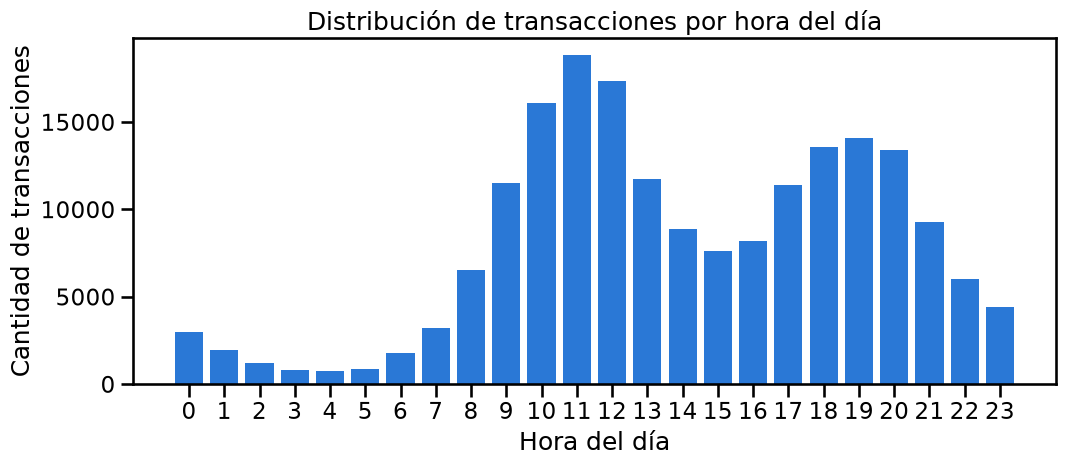

In [51]:
#  5. Visualización: distribución horaria
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(dist_hora.index, dist_hora.values, color='#2a78d6')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Cantidad de transacciones')
ax.set_title('Distribución de transacciones por hora del día')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

Se observa dos momentos del día con mayor actividad: el primero es a la mañana, entre las 10 y 12 hs  y el segundo momento por la tarde, entre las 18 y 20 hs.

Agrupando por franja horaria, la noche (19-24 hs) concentra el 24,54% del
total de transacciones, seguida por la mañana (06-12 hs) con 30.14% , luego la
Tarde (15-19hs) con 21,17% y el Mediodia (12-15hs) con el 17,71%. La madrugada (00-06 hs) es, la franja de menor actividad, representando apenas el 4.45% del total.

Dado que la madrugada es un horario de actividad marcadamente baja bajo
condiciones normales, se identifica como una franja de particular interés
para el análisis de fraude en la sección siguiente: una concentración
desproporcionada de casos fraudulentos en este rango horario (respecto de su
4.45% de participación habitual) constituiría una señal relevante para el
modelo de detección.

### ¿Qué rubros son los más frecuentes? ¿Qué rubros son los que más importe gastan los clientes?

Se identifican los rubros comerciales con mayor cantidad de transacciones,
excluyendo las transacciones sin rubro aplicable (Trx_RubroRed = -1) dado que no corresponden a compra.

Se identifican los rubros con mayor gasto total y promedio por transacción,
para distinguir entre rubros de alta frecuencia y rubros de alto monto.

In [52]:
# ============================================
#    Rubros más frecuentes y de mayor gasto
# ============================================

# transacciones que tienen rubro
df_validos = df[df['Trx_RubroRed'] != -1].copy()

# 1. Rubros más frecuentes
top_frecuencia = df_validos['Rubro_Descripcion'].value_counts().head(15)

print("=== 1. Top 15 rubros más frecuentes (por cantidad de transacciones) ===")
print(top_frecuencia)

#  2. Rubros con mayor gasto TOTAL
gasto_total_rubro = df_validos.groupby('Rubro_Descripcion')['Trx_Importe'].sum().sort_values(ascending=False).head(15)

print("\n=== 2. Top 15 rubros por gasto TOTAL ===")
print(gasto_total_rubro)

# 3. Rubros con mayor gasto PROMEDIO por transacción
gasto_promedio_rubro = df_validos.groupby('Rubro_Descripcion')['Trx_Importe'].mean().sort_values(ascending=False).head(15)

print("\n=== 3. Top 15 rubros por gasto PROMEDIO por transacción ===")
print(gasto_promedio_rubro)

#  4. Tabla resumen: frecuencia vs gasto total vs gasto promedio (para los rubros más frecuentes)
resumen_rubros = df_validos.groupby('Rubro_Descripcion')['Trx_Importe'].agg(
    Cantidad_Trx='count',
    Gasto_Total='sum',
    Gasto_Promedio='mean'
).sort_values('Cantidad_Trx', ascending=False).head(15)

print("\n=== 4. Resumen: Top 15 rubros más frecuentes (frecuencia + gasto) ===")
print(resumen_rubros)


=== 1. Top 15 rubros más frecuentes (por cantidad de transacciones) ===
Rubro_Descripcion
Tiendas de comestibles, supermercados                                                                          17213
Servicios profesionales: no clasificados en otra parte                                                          6826
Estaciones de servicio (con o sin servicios auxiliares)                                                         6550
Farmacias                                                                                                       4058
Grandes almacenes (Tiendas departamentales)                                                                     4052
Proveedores de carne para congeladores y taquillas                                                              2931
Pagos de impuestos                                                                                              2772
Almacenamiento público; productos agrícolas, productos refrigerados, almacenamiento de artí

El rubro más frecuente es "Tiendas de comestibles, supermercados" con 17,213
transacciones, seguido de servicios profesionales, estaciones de servicio y
farmacias,  consistentes con patrones de consumo cotidiano.

Al analizar el gasto, supermercados también lidera en monto total \$438M.
Sin embargo, se destaca el rubro "Casi efectivo (Quasi Cash): Comerciante",
que si bien ocupa el 9° lugar en frecuencia (2.455 transacciones), se ubica
2° en gasto total \$244.8M y presenta el gasto promedio por transacción
más alto entre los rubros de uso frecuente \$99,728, muy por encima de
supermercados con \$25,449 o farmacias con \$29,538.

Las operaciones "quasi-cash" (retiro de efectivo disfrazado de compra, cambio de cheques, fichas, entre otros), un tipo de operación frecuentemente asociada a fraude y lavado de activos en la detección de fraude bancario.

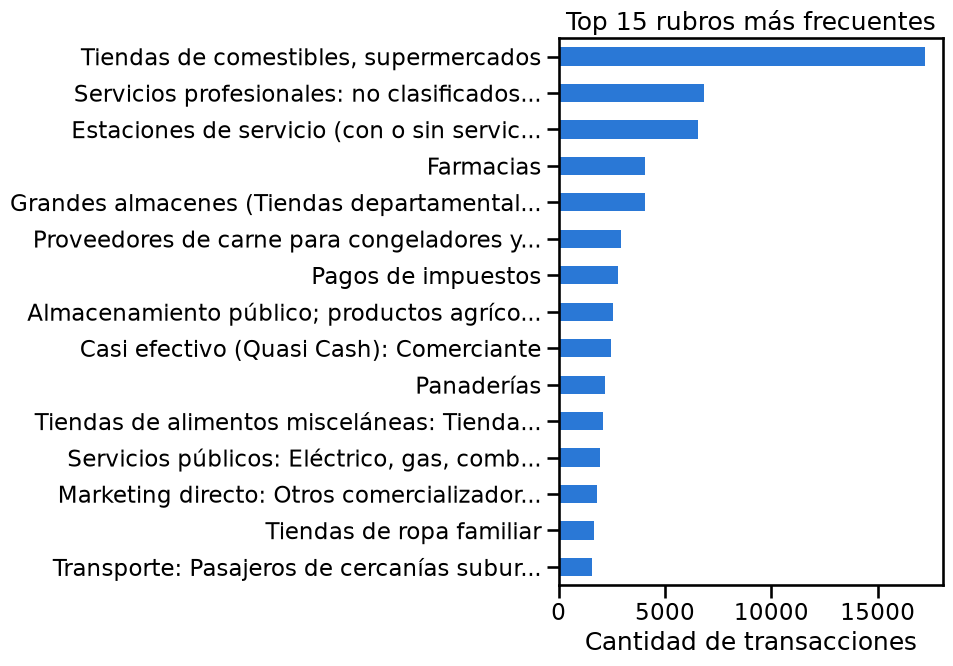

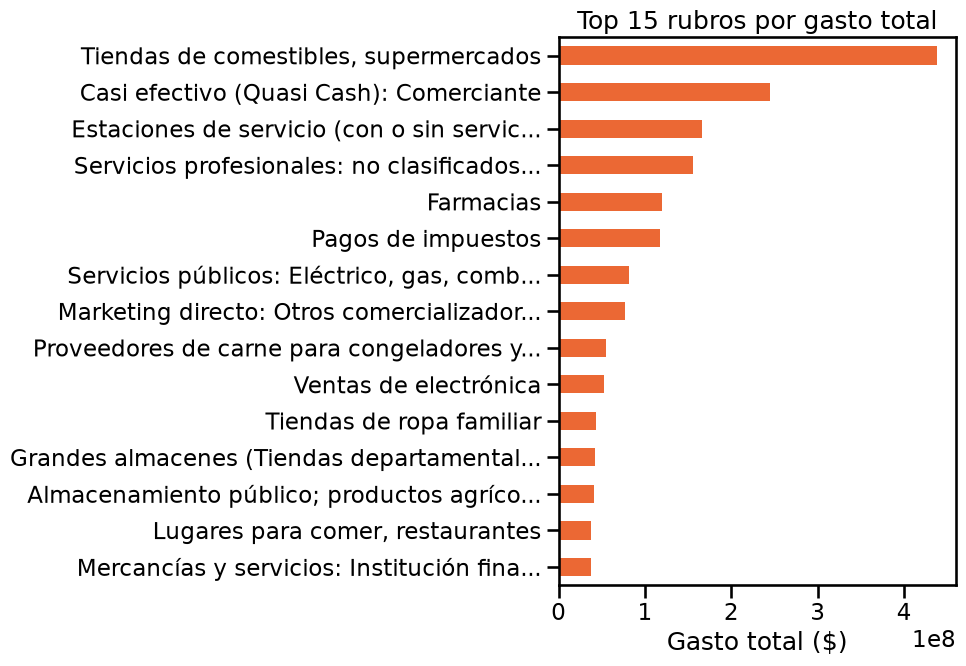

In [53]:
#5. Visualización
def truncar_texto(texto, max_len=40):
    return texto if len(texto) <= max_len else texto[:max_len].rstrip() + '...'

#  Gráfico 1: Top 15 rubros más frecuentes
top_frecuencia_corto = top_frecuencia.copy()
top_frecuencia_corto.index = [truncar_texto(x) for x in top_frecuencia_corto.index]

fig, ax = plt.subplots(figsize=(10, 7))
top_frecuencia_corto.plot(kind='barh', ax=ax, color='#2a78d6')
ax.set_xlabel('Cantidad de transacciones')
ax.set_ylabel('')
ax.set_title('Top 15 rubros más frecuentes')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#  Gráfico 2: Top 15 rubros por gasto total ---
gasto_total_corto = gasto_total_rubro.copy()
gasto_total_corto.index = [truncar_texto(x) for x in gasto_total_corto.index]

fig, ax = plt.subplots(figsize=(10, 7))
gasto_total_corto.plot(kind='barh', ax=ax, color='#eb6834')
ax.set_xlabel('Gasto total ($)')
ax.set_ylabel('')
ax.set_title('Top 15 rubros por gasto total')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### ¿Qué tipo de movimiento se realiza más?

Se identifican los tipos de movimiento más frecuentes, utilizando la tabla
de referencia CodigoMovimientos (Dr_Muestra.xlsx)

In [54]:
# ============================================
#      Tipo de movimiento más frecuente
# ============================================

#  1. Leer tabla de referencia CodigoMovimientos
CodigoMovimientos = pd.read_excel(
    'Dr_Muestra.xlsx',
    sheet_name='CodigoMovimientos',
    skiprows=1
)
CodigoMovimientos.columns = ['Codigo', 'Movimiento_Descripcion']
CodigoMovimientos['Codigo'] = CodigoMovimientos['Codigo'].astype(int)

#  2. Merge con el dataset principal
df['Movimiento_Codigo'] = df['Movimiento_Codigo'].astype(int)
df = df.merge(
    CodigoMovimientos,
    left_on='Movimiento_Codigo',
    right_on='Codigo',
    how='left'
).drop(columns=['Codigo'])

# 3. Distribución de tipos de movimiento
top_movimientos = df['Movimiento_Descripcion'].value_counts().head(15)

print("=== Top 15 tipos de movimiento más frecuentes ===")
print(top_movimientos)

print("\nEn porcentaje del total:")
print((top_movimientos / len(df) * 100).round(2))

=== Top 15 tipos de movimiento más frecuentes ===
Movimiento_Descripcion
Compras Maestro POSNet                               81463
Transferencia HomeBanking                            29499
DEBIN                                                26970
Extracción ATM propio banco                          20637
Débito DEBIN                                         12307
Compra en el exterior con tarjeta de débito           5909
Pago automatico de servicios ATM/HomeBanking          5140
Pago con Transferencia Modo                           2412
Transferencia por Modo                                1957
Extracción ATM no propio                              1928
Compra Cash Back PosNet en Comercio                   1666
Pago de resumen desde Cajero / HomeBanking            1298
Débito por transferencia ATM propio / HomeBanking      349
Devolución débito en cuenta posnet                     263
Compras por Cajero / HomeBanking Propio                195
Name: count, dtype: int64

En porcentaje d

El tipo de movimiento más frecuente es "Compras Maestro POSNet", con 81.463
transacciones (42.31% del total).En segundo y tercer lugar se ubican movimientos de transferencia: "Transferencia HomeBanking" (15.32%) y "DEBIN" (14.01%), seguidos de "Débito DEBIN" (6.39%). En conjunto, los movimientos de transferencia y débito directo representan aproximadamente el 35.7% del dataset.
"Extracción ATM propio banco" (10.72%) es el cuarto movimiento más frecuente,
correspondiente a extracciones tradicionales de efectivo. El resto de los
movimientos: compras en el exterior, pagos automáticos de servicios, cash
back, entre otros, tienen participación individual menor al 3.1%,
completando un panorama de comportamiento transaccional diverso pero
concentrado en pocos tipos de operación dominantes.

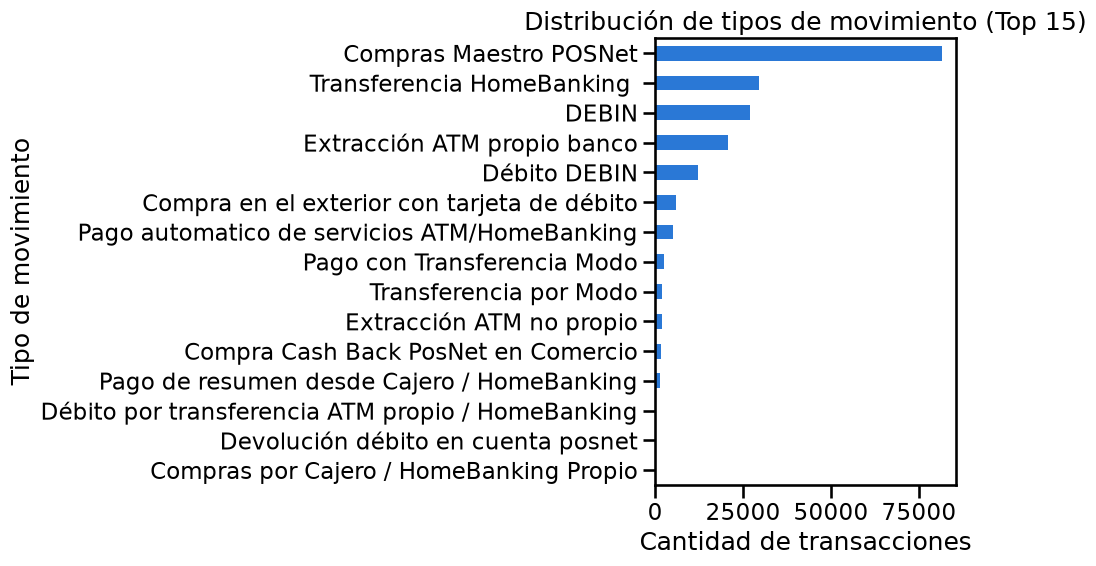

In [55]:
#  4. Visualización
fig, ax = plt.subplots(figsize=(10, 6))
top_movimientos.plot(kind='barh', ax=ax, color='#2a78d6')
ax.set_xlabel('Cantidad de transacciones')
ax.set_ylabel('Tipo de movimiento')
ax.set_title('Distribución de tipos de movimiento (Top 15)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### ¿El cliente estuvo presente en la compra?

El dataset no cuenta con una variable explícita de "presencia del cliente".
Se infiere a partir de Trx_TipoTerminal, clasificando cada canal según si
requiere presencia física del cliente o si corresponde a un canal remoto. Esta clasificación se valida cruzando con Trx_ModoIngreso.

In [56]:
# ============================================
#   ¿El cliente estuvo presente en la compra?
# ============================================

#  1. Clasificación de canales según presencia física
mapa_presencia = {
    0: 'Presencial',       # Red de la competencia (cajero físico de otro banco)
    1: 'Presencial',       # Cajero automático físico marca X
    2: 'Presencial',       # Cajero automático físico marca Y
    3: 'No presencial',    # Operación web/app del banco
    4: 'Presencial',       # Tótem/terminal de autoservicio en sucursal
    5: 'No presencial',    # Compra online con Maestro
    6: 'No presencial',    # Credenciales guardadas - suscripciones
    7: 'No presencial',    # Credenciales guardadas - pagos recurrentes
    8: 'No presencial',    # Pago de impuestos/servicios vía web
    9: 'No presencial',    # Canal exclusivo del banco (app/telefónica)
    10: 'No presencial',   # Pago en terminal no bancaria
    11: 'No presencial',   # Compra por internet con débito Mastercard
    12: 'Presencial'       # Compra presencial con mPOS
}

df['Presencia_Cliente'] = df['Trx_TipoTerminal'].astype(int).map(mapa_presencia)

#2. Distribución general
dist_presencia = df['Presencia_Cliente'].value_counts()
print("=== Distribución===")
print(dist_presencia)
print("\nEn porcentaje:")
print((dist_presencia / len(df) * 100).round(2))

#3. Validación cruzando con Trx_ModoIngreso
print("\n=== Validación: Presencia vs. Modo de Ingreso de tarjeta ===")
print(pd.crosstab(df['Presencia_Cliente'], df['Trx_ModoIngreso']))



=== Distribución===
Presencia_Cliente
Presencial       126523
No presencial     65993
Name: count, dtype: int64

En porcentaje:
Presencia_Cliente
Presencial      65.720000
No presencial   34.280000
Name: count, dtype: float64

=== Validación: Presencia vs. Modo de Ingreso de tarjeta ===
Trx_ModoIngreso        A   B    C    D      E      F    G
Presencia_Cliente                                        
No presencial      65972  21    0    0      0      0    0
Presencial         37137   0  172  311  32480  56249  174


Se estima que el 65.72% de las transacciones (126,523) corresponden a
operaciones presenciales,es decir, con el cliente físicamente en un cajero
automático o realizando una compra con mPOS, mientras que el 34.28%
(65,993) corresponden a operaciones no presenciales.

Esta clasificación se valida cruzando con Trx_ModoIngreso:las
transacciones "No presenciales" utiliza mayoritariamente, 65.972 de 65.993, el modo de ingreso "A" (Terminal NO EMV). En cambio, las transacciones
"Presenciales" se distribuyen mayormente entre modos que sí implican lectura
física de la tarjeta: chip (E, 32,480 casos), contactless (F, 56,249 casos),
magstripe (C, 172 casos) y fallback a banda magnética (D, 311 casos),
reforzando la validez del criterio de clasificación utilizado.

Esta variable (Presencia_Cliente) resulta un candidato relevante para el
modelo de fraude, dado que las transacciones no presenciales suelen
representar un perfil de riesgo.

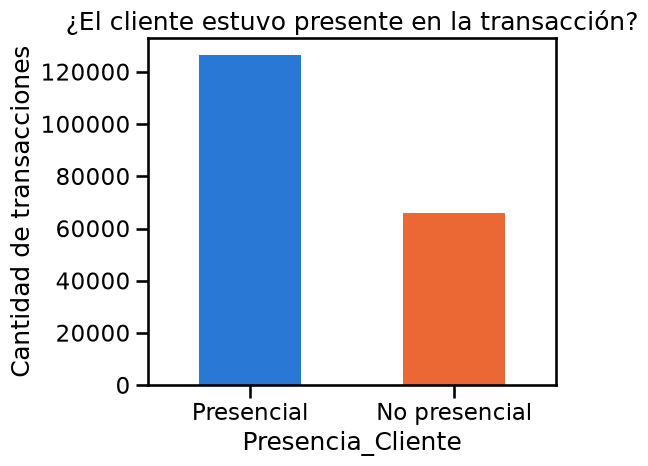

In [57]:
#4. Visualización
fig, ax = plt.subplots(figsize=(6, 5))
dist_presencia.plot(kind='bar', ax=ax, color=['#2a78d6', '#eb6834'])
ax.set_ylabel('Cantidad de transacciones')
ax.set_title('¿El cliente estuvo presente en la transacción?')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### Fraude vs. No Fraude

Se compara el comportamiento transaccional entre transacciones fraudulentas
y no fraudulentas a lo largo de las principales variables analizadas en las
secciones anteriores, con el objetivo de identificar patrones distintivos
que puedan aportar señal al modelo de detección de fraude.


### Fraude vs. No Fraude — Hora del día y Día de la semana

=== Distribución por hora del día (% dentro de cada clase) ===


          No Fraude   Fraude
Hora_Dia                    
0          1.537215 4.515050
1          0.988396 4.096990
2          0.613632 3.428094
3          0.392013 2.842809
4          0.386264 2.508361
5          0.442714 1.254181
6          0.916789 2.341137
7          1.670500 1.923077
8          3.409471 2.424749
9          6.017667 1.755853
10         8.367656 5.769231
11         9.816538 6.103679
12         9.034079 4.515050
13         6.091365 6.187291
14         4.598056 6.103679
15         3.939473 5.016722
16         4.258311 3.428094
17         5.935083 4.431438
18         7.060945 5.016722
19         7.327514 5.183946
20         6.974179 7.023411
21         4.810266 4.682274
22         3.117813 5.936455
23         2.294062 3.511706


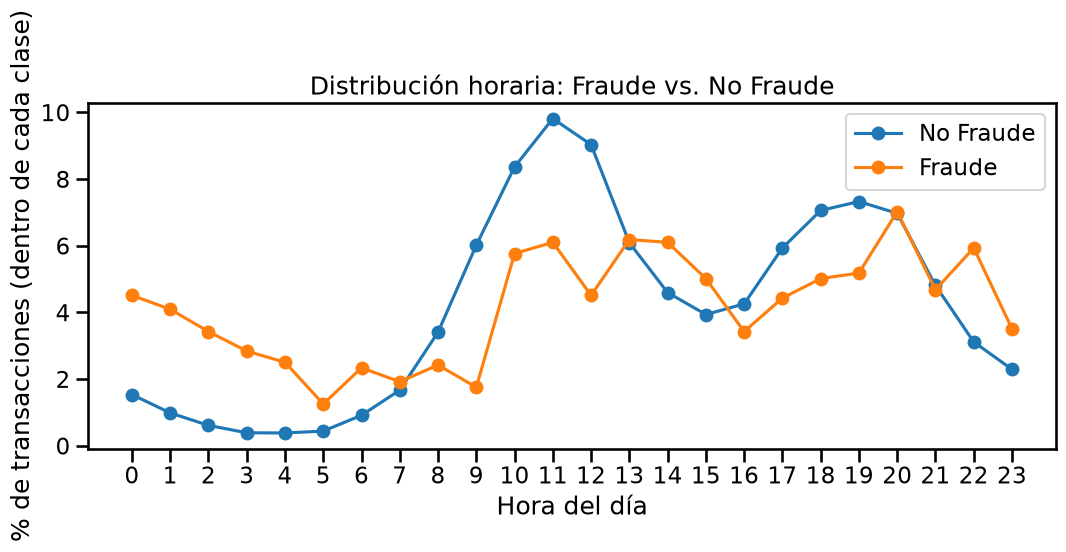


=== Distribución por día de la semana (% dentro de cada clase) ===
            No Fraude    Fraude
Dia_Semana                     
Lunes       14.217541 18.896321
Martes      14.880828 13.210702
Miércoles   15.113423 13.377926
Jueves      15.811729 12.458194
Viernes     16.865984 15.217391
Sábado      14.301171 14.966555
Domingo      8.809325 11.872910


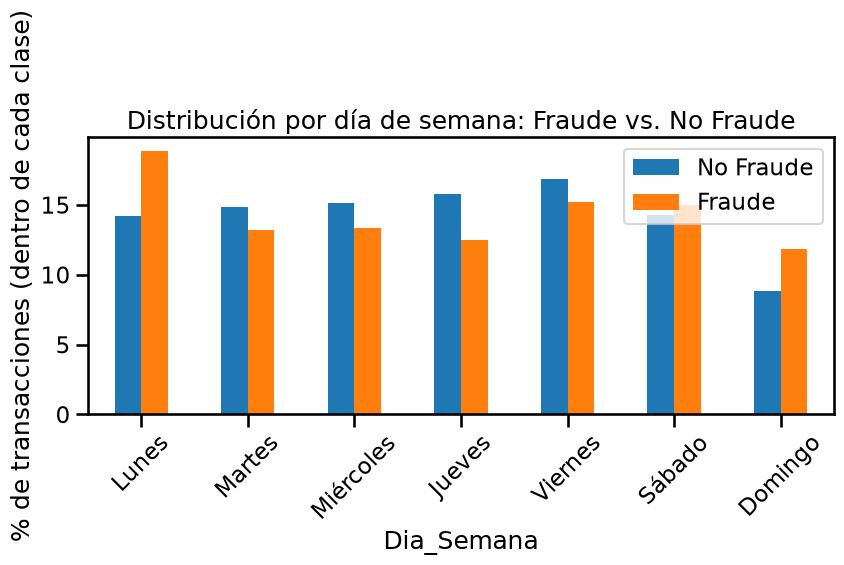

In [58]:
# --- Hora del día ---
tabla_hora = pd.crosstab(df['Es_Fraude'], df['Hora_Dia'], normalize='index') * 100
tabla_hora.index = ['No Fraude', 'Fraude']
print("=== Distribución por hora del día (% dentro de cada clase) ===")
print(tabla_hora.T)

fig, ax = plt.subplots(figsize=(11, 5))
tabla_hora.T.plot(ax=ax, marker='o')
ax.set_xlabel('Hora del día')
ax.set_ylabel('% de transacciones (dentro de cada clase)')
ax.set_title('Distribución horaria: Fraude vs. No Fraude')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

# --- Día de la semana ---
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
tabla_dia = pd.crosstab(df['Es_Fraude'], df['Dia_Semana'], normalize='index').reindex(columns=orden_dias) * 100
tabla_dia.index = ['No Fraude', 'Fraude']
print("\n=== Distribución por día de la semana (% dentro de cada clase) ===")
print(tabla_dia.T)

fig, ax = plt.subplots(figsize=(9, 5))
tabla_dia.T.plot(kind='bar', ax=ax)
ax.set_ylabel('% de transacciones (dentro de cada clase)')
ax.set_title('Distribución por día de semana: Fraude vs. No Fraude')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Se detecta fraude principalmente los días lunes,seguido de los días viernes y sábados. La franca horaria prevaleciente es entre las 10 y 12 hs y entre las 18 y 20 hs.

### Fraude vs. No Fraude — Tiempo entre transacciones

=== Tiempo entre transacciones (horas) — por clase ===


                  count      mean        std      min      25%      50%  \
Es_Fraude                                                                 
0         190611.000000 28.973607  87.768981 0.000000 0.478889 6.903333   
1           1189.000000 55.078409 326.925549 0.000000 0.028611 0.627500   

                75%         max  
Es_Fraude                        
0         24.705278 7110.018333  
1         14.885278 6388.803056  


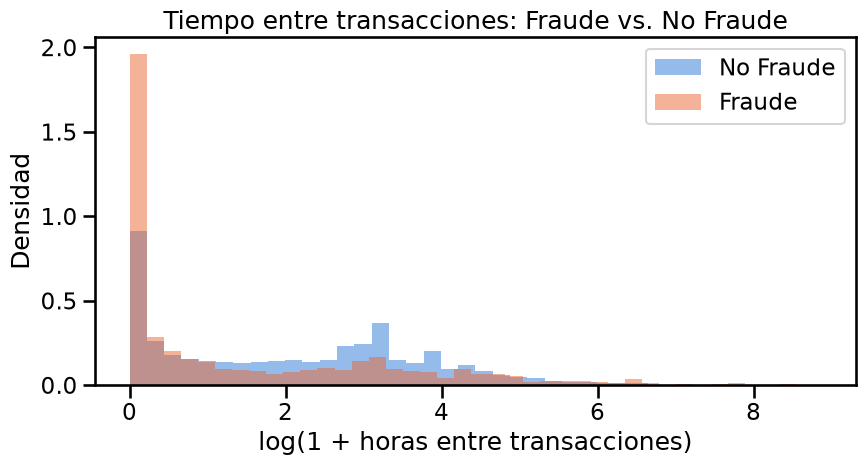

In [59]:
#==================================
# Tiempo entre transacciones
#==================================

print("=== Tiempo entre transacciones (horas) — por clase ===")
print(df.groupby('Es_Fraude')['Tiempo_Entre_Trx_Horas'].describe())

fig, ax = plt.subplots(figsize=(9, 5))
for clase, label, color in [(0, 'No Fraude', '#2a78d6'), (1, 'Fraude', '#eb6834')]:
    datos = df[df['Es_Fraude']==clase]['Tiempo_Entre_Trx_Horas'].dropna()
    ax.hist(np.log1p(datos), bins=40, alpha=0.5, label=label, color=color, density=True)
ax.set_xlabel('log(1 + horas entre transacciones)')
ax.set_ylabel('Densidad')
ax.set_title('Tiempo entre transacciones: Fraude vs. No Fraude')
ax.legend()
plt.tight_layout()
plt.show()

### Fraude vs. No Fraude — Tipo de movimiento y moneda

In [60]:
# --- Moneda (pesos/dólares) ---
tabla_moneda = pd.crosstab(df['Trx_Moneda'], df['Es_Fraude'], normalize='index') * 100
tabla_moneda.index = ['Pesos', 'Dólares']
tabla_moneda.columns = ['No Fraude', 'Fraude']
print("=== Tasa de fraude por moneda ===")
print(tabla_moneda)

# --- Tipo de movimiento ---
stats_movimiento = df.groupby('Movimiento_Descripcion')['Es_Fraude'].agg(['count', 'mean'])
stats_movimiento = stats_movimiento[stats_movimiento['count'] >= 30].sort_values('mean', ascending=False)
stats_movimiento['tasa_fraude_%'] = stats_movimiento['mean'] * 100
print("\n=== Tipos de movimiento con mayor tasa de fraude (mín. 30 transacciones) ===")
print(stats_movimiento[['count', 'tasa_fraude_%']].head(15))

=== Tasa de fraude por moneda ===
         No Fraude   Fraude
Pesos    99.661733 0.338267
Dólares  90.547097 9.452903

=== Tipos de movimiento con mayor tasa de fraude (mín. 30 transacciones) ===
                                                   count  tasa_fraude_%
Movimiento_Descripcion                                                 
Compra en el exterior con tarjeta de débito         5909       9.561686
Compras Maestro POSNet                             81463       0.764764
Compra Cash Back PosNet en Comercio                 1666       0.480192
Comisión ATM no propio / Banelco                      60       0.000000
Comisión ATM LINK no propio                          172       0.000000
Compras por Cajero / HomeBanking Propio              195       0.000000
DEBIN                                              26970       0.000000
Devolución débito en cuenta posnet                   263       0.000000
Débito DEBIN                                       12307       0.000000
Débito por t

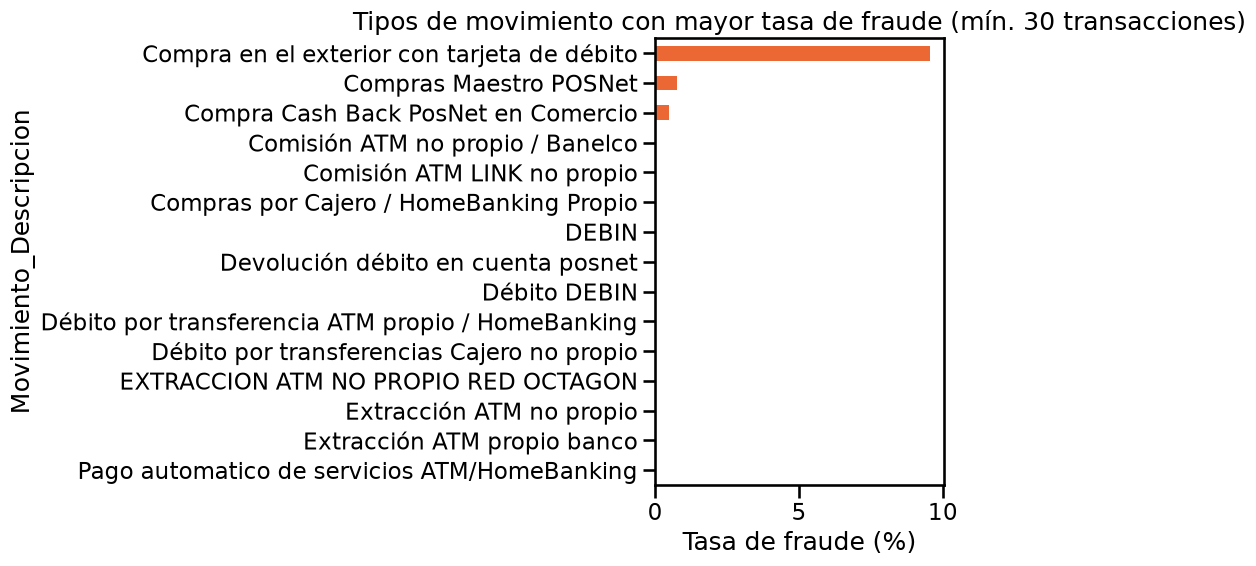

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))
stats_movimiento['tasa_fraude_%'].head(15).plot(kind='barh', ax=ax, color='#eb6834')
ax.set_xlabel('Tasa de fraude (%)')
ax.set_title('Tipos de movimiento con mayor tasa de fraude (mín. 30 transacciones)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

La moneda con mayor porcentaje en que se comete fraude es el dólar con más del 9%, y se realiza en compras en el exterior con tarjeta de débito.

### Fraude vs. No Fraude — Tipo de terminal e ID de terminal

In [62]:
# --- Tipo de terminal ---
tabla_tipo_terminal = pd.crosstab(df['Es_Fraude'], df['Trx_TipoTerminal'], normalize='index') * 100
tabla_tipo_terminal.index = ['No Fraude', 'Fraude']
print("=== Tipo de terminal (% dentro de cada clase) ===")
print(tabla_tipo_terminal.T)

# --- ID de terminal (Trx_TerminalRed) ---
stats_terminal = df.groupby('Trx_TerminalRed')['Es_Fraude'].agg(['count', 'mean'])
stats_terminal = stats_terminal[stats_terminal['count'] >= 30].sort_values('mean', ascending=False)
stats_terminal['tasa_fraude_%'] = stats_terminal['mean'] * 100
print("\n=== Terminales con mayor tasa de fraude (mín. 30 transacciones) ===")
print(stats_terminal[['count', 'tasa_fraude_%']].head(15))

=== Tipo de terminal (% dentro de cada clase) ===
                  No Fraude    Fraude
Trx_TipoTerminal                     
0                 34.755384  9.698997
1                 11.980974  0.000000
2                  0.000523  0.000000
3                  7.698620  0.000000
4                 18.992264  0.000000
5                  0.002613  0.000000
6                  1.230922  5.267559
7                  2.236044 15.384615
8                  0.003136  0.000000
9                 14.948254  0.000000
10                 0.009931  0.000000
11                 7.829291 64.882943
12                 0.312043  4.765886

=== Terminales con mayor tasa de fraude (mín. 30 transacciones) ===
                  count  tasa_fraude_%
Trx_TerminalRed                       
3244343043363043     55      98.181818
4538343836434532     90      81.111111
4634354636424333     65      76.923077
3346364246434539     33      48.484848
4242343642323331     34      29.411765
3633454142343332     60      25.000000

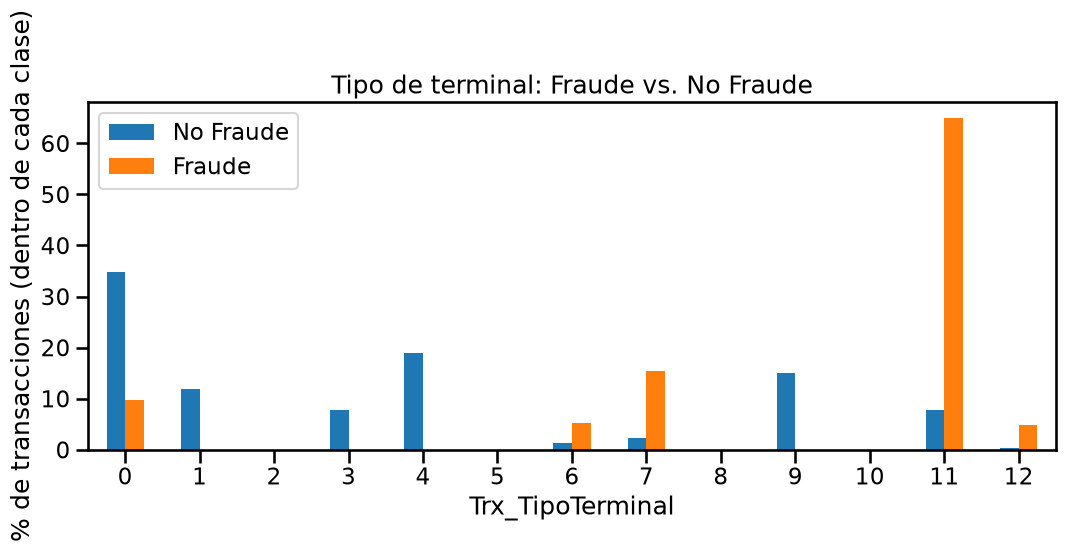

In [63]:
fig, ax = plt.subplots(figsize=(11, 5))
tabla_tipo_terminal.T.plot(kind='bar', ax=ax)
ax.set_ylabel('% de transacciones (dentro de cada clase)')
ax.set_title('Tipo de terminal: Fraude vs. No Fraude')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

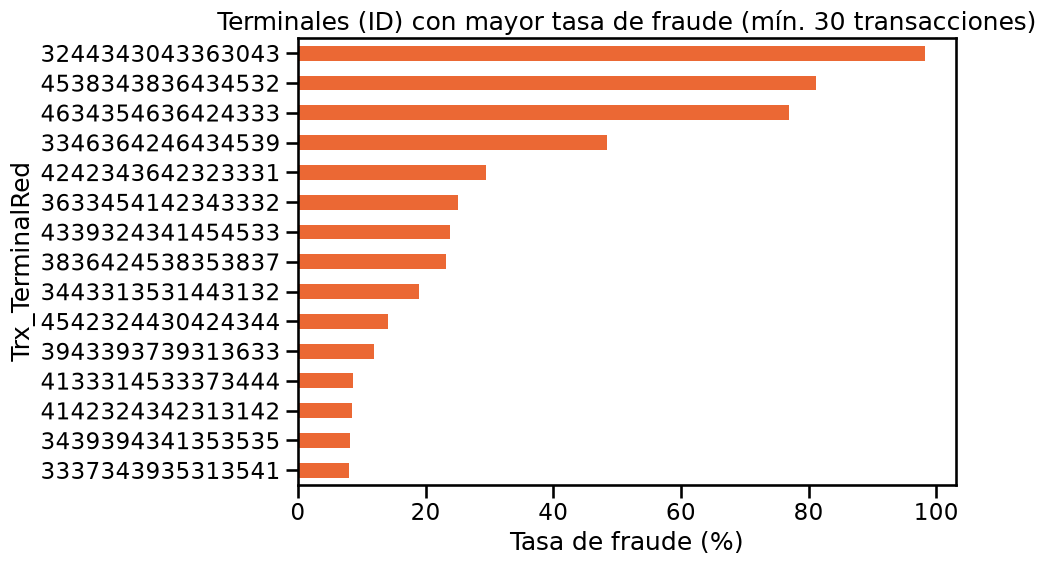

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))
stats_terminal['tasa_fraude_%'].head(15).plot(kind='barh', ax=ax, color='#eb6834')
ax.set_xlabel('Tasa de fraude (%)')
ax.set_title('Terminales (ID) con mayor tasa de fraude (mín. 30 transacciones)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

La terminal 11 representa el mayor porcentaje de fraude (64,88%) correspondiente a Compras por internet realizadas específicamente con tarjeta de débito Mastercard, agrupadas en Compras y E-commerce.

### Fraude vs. No Fraude — Ciudad de la transacción


Se normalizó Trx_CiudadTerminal (mayúsculas, espacios y acentos) para evitar que variantes de formato (ej. Mountain View/MOUNTAIN VIEW) fragmenten el conteo por ciudad.


In [65]:
#Realizamos la normalización de texto.
def normalizar_texto(s):
    if pd.isna(s):
        return s
    s = s.strip().upper()
    s = ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )
    return s

df['Trx_CiudadTerminal_norm'] = df['Trx_CiudadTerminal'].apply(normalizar_texto)

print(f"Ciudades únicas antes: {df['Trx_CiudadTerminal'].nunique()}")
print(f"Ciudades únicas después: {df['Trx_CiudadTerminal_norm'].nunique()}")

Ciudades únicas antes: 3045
Ciudades únicas después: 2573


In [66]:
stats_ciudad = df.groupby('Trx_CiudadTerminal_norm')['Es_Fraude'].agg(['count', 'mean'])
stats_ciudad = stats_ciudad[stats_ciudad['count'] >= 50].sort_values('mean', ascending=False)
stats_ciudad['tasa_fraude_%'] = stats_ciudad['mean'] * 100
print("=== Ciudades con mayor tasa de fraude (mín. 50 transacciones) ===")
print(stats_ciudad[['count', 'tasa_fraude_%']].head(15))

=== Ciudades con mayor tasa de fraude (mín. 50 transacciones) ===
                         count  tasa_fraude_%
Trx_CiudadTerminal_norm                      
QUIBDO                      55      98.181818
MIAMI                       54      40.740741
DUBLIN                     164      22.560976
MOUNTAIN VIEW             1214      14.497529
LONDON                      78      12.820513
SANTA FE                    78      11.538462
ROSARIO                    545       6.422018
CUPERTNO                   144       4.166667
PROV BS AIRES              146       3.424658
CENTRO-MICROC              768       3.255208
CABA                      1603       3.056769
G.CO/HELPPAY#              145       2.758621
CIUDAD AUTONO               76       2.631579
CAPITAL                    197       2.030457
CAPITAL FEDER             5430       1.804788


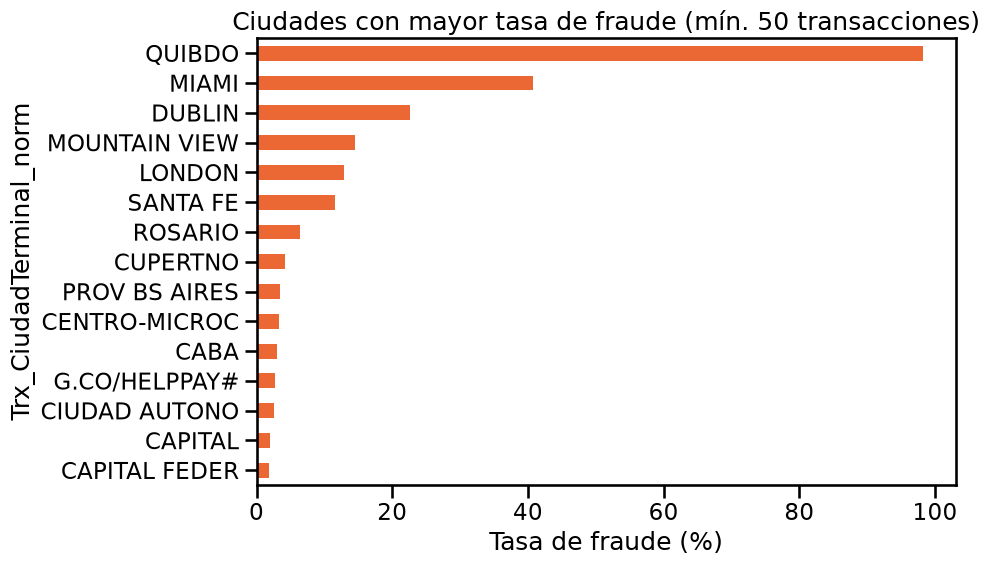

In [67]:
fig, ax = plt.subplots(figsize=(10, 6))
stats_ciudad['tasa_fraude_%'].head(15).plot(kind='barh', ax=ax, color='#eb6834')
ax.set_xlabel('Tasa de fraude (%)')
ax.set_title('Ciudades con mayor tasa de fraude (mín. 50 transacciones)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

QUIBDO es la ciudad con mayor tasa de fraude (98.2%, n=55), seguido de ciudades internacionales como Miami, Dublín y Londres, consistente con el mayor riesgo ya observado en transacciones en dólares

### Fraude vs. No Fraude — Rubro de compra

In [68]:
df_validos = df[df['Trx_RubroRed'] != -1]

stats_rubro = df_validos.groupby('Rubro_Descripcion')['Es_Fraude'].agg(['count', 'mean'])
stats_rubro = stats_rubro[stats_rubro['count'] >= 30].sort_values('mean', ascending=False)
stats_rubro['tasa_fraude_%'] = stats_rubro['mean'] * 100
print("=== Rubros con mayor tasa de fraude (mín. 30 transacciones) ===")
print(stats_rubro[['count', 'tasa_fraude_%']].head(15))

=== Rubros con mayor tasa de fraude (mín. 30 transacciones) ===
                                                    count  tasa_fraude_%
Rubro_Descripcion                                                       
Servicios de citas                                     32      50.000000
Servicios de publicidad                               208      34.615385
Servicios de programación de computadoras, proc...    331      30.815710
Organizaciones caritativas y de servicio social        56      26.785714
Marketing directo: Comerciantes de continuidad/...    118      22.033898
Productos digitales: Aplicaciones de software (...    237      16.455696
Servicios de recreación: no clasificados en otr...     33      12.121212
Servicios empresariales: no clasificados en otr...    117      11.965812
Tiendas de equipos, muebles y artículos para el...    104       9.615385
Servicios de consultoría, gestión y relaciones ...     59       8.474576
Tiendas de ropa deportiva y de equitación              95   

C:\Users\Mauri\AppData\Local\Temp\ipykernel_2572\1014285393.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


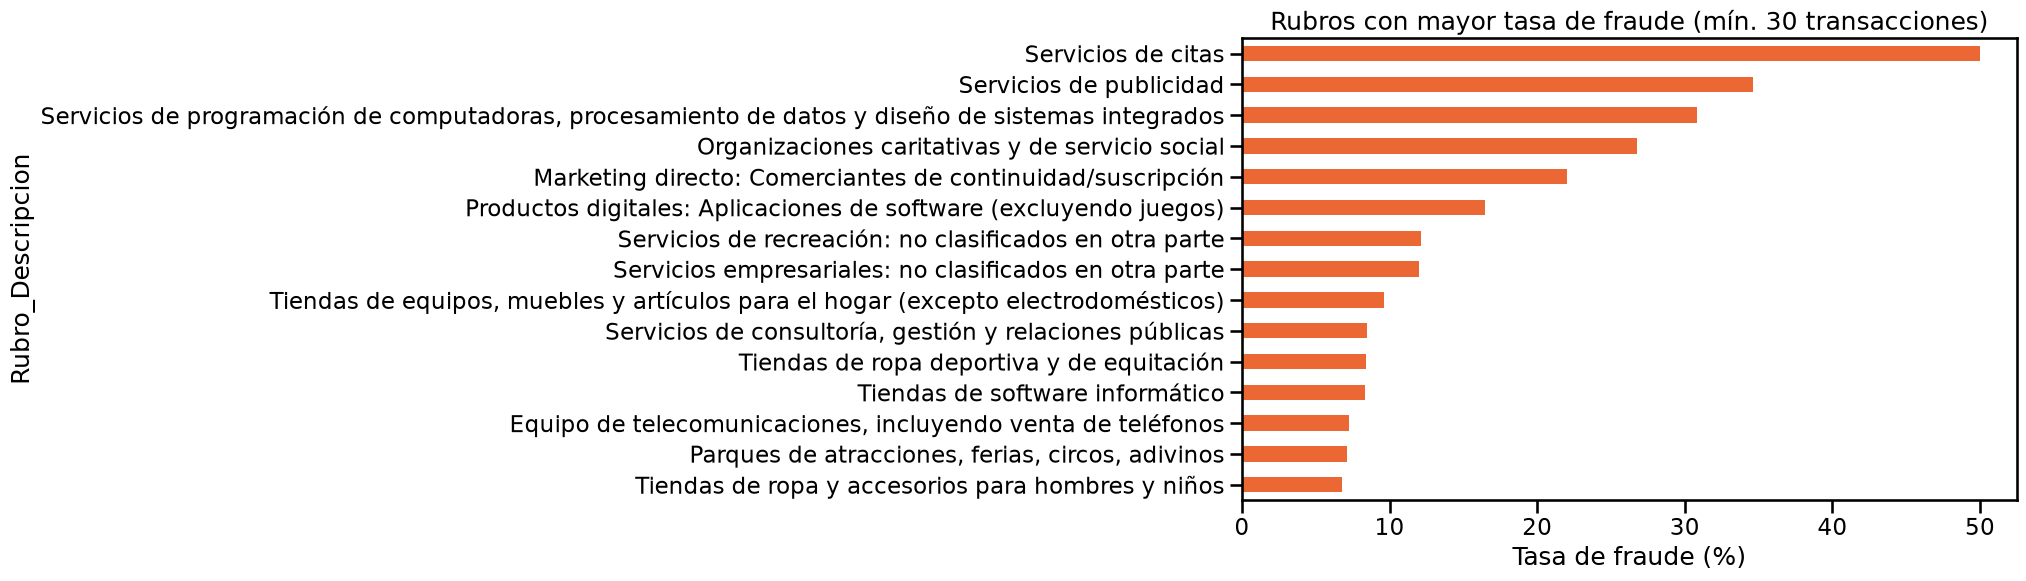

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))
stats_rubro['tasa_fraude_%'].head(15).plot(kind='barh', ax=ax, color='#eb6834')
ax.set_xlabel('Tasa de fraude (%)')
ax.set_title('Rubros con mayor tasa de fraude (mín. 30 transacciones)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Los rubros con mayor tasa de fraude son Servicios de citas con el 50%, seguido por Servicios de publicidad con el 34% y luego, servicios de programación de computadoras, con el 31%

### Fraude vs. No Fraude — Comparativo Rubro x Ciudad

In [70]:
stats_rubro_ciudad = df_validos.groupby(['Rubro_Descripcion', 'Trx_CiudadTerminal'])['Es_Fraude'].agg(['count', 'mean'])
stats_rubro_ciudad = stats_rubro_ciudad[stats_rubro_ciudad['count'] >= 20].sort_values('mean', ascending=False)
stats_rubro_ciudad['tasa_fraude_%'] = stats_rubro_ciudad['mean'] * 100
print("=== Top 10 combinaciones Rubro x Ciudad con mayor tasa de fraude (mín. 20 transacciones) ===")
print(stats_rubro_ciudad[['count', 'tasa_fraude_%']].head(10))

=== Top 10 combinaciones Rubro x Ciudad con mayor tasa de fraude (mín. 20 transacciones) ===
                                                                       count  \
Rubro_Descripcion                                  Trx_CiudadTerminal          
Productos digitales: Aplicaciones de software (... MIAMI                  21   
Servicios de programación de computadoras, proc... QUIBDO                 55   
Casi efectivo (Quasi Cash): Comerciante            CAPITAL FEDER          90   
Servicios de publicidad                            MOUNTAIN VIEW          65   
Servicios de telecomunicaciones, incluidos, ent... CAP.FEDERAL            28   
Tiendas de software informático                    6502530000             33   
Grandes almacenes (Tiendas departamentales)        Dublin                 34   
Pagos de impuestos                                 CABA                   28   
Servicios públicos: Eléctrico, gas, combustible... ROSARIO                80   
Servicios de programación d

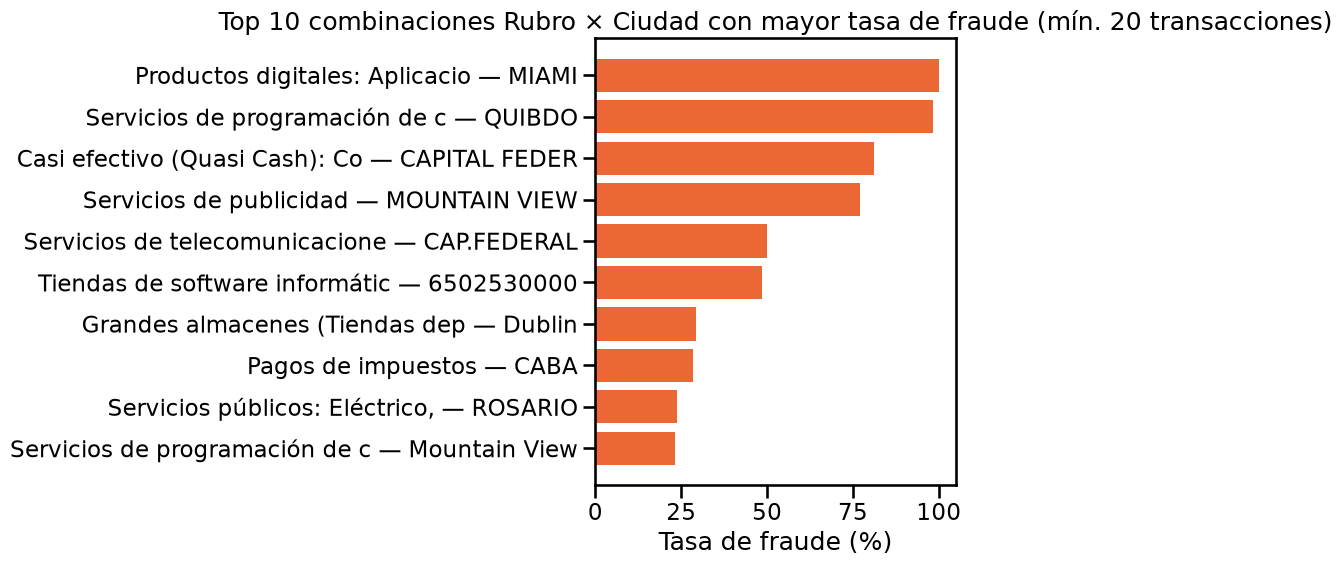

In [71]:
top10 = stats_rubro_ciudad['tasa_fraude_%'].head(10)
etiquetas = [f"{rubro[:30]} — {ciudad}" for rubro, ciudad in top10.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(etiquetas, top10.values, color='#eb6834')
ax.set_xlabel('Tasa de fraude (%)')
ax.set_title('Top 10 combinaciones Rubro × Ciudad con mayor tasa de fraude (mín. 20 transacciones)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Rubros más frecuentes específicamente en transacciones fraudulentas

In [72]:
top_rubros_fraude = df_validos[df_validos['Es_Fraude']==1]['Rubro_Descripcion'].value_counts().head(15)
print("=== Rubros más frecuentes EN transacciones fraudulentas ===")
print(top_rubros_fraude)

=== Rubros más frecuentes EN transacciones fraudulentas ===
Rubro_Descripcion
Tiendas de software informático                                                                      112
Servicios de programación de computadoras, procesamiento de datos y diseño de sistemas integrados    102
Casi efectivo (Quasi Cash): Comerciante                                                               97
Servicios profesionales: no clasificados en otra parte                                                75
Servicios de publicidad                                                                               72
Servicios públicos: Eléctrico, gas, combustible para calefacción, sanitario, agua                     69
Productos digitales: Aplicaciones de software (excluyendo juegos)                                     39
Pagos de impuestos                                                                                    37
Tiendas de comestibles, supermercados                                             

C:\Users\Mauri\AppData\Local\Temp\ipykernel_2572\897246207.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


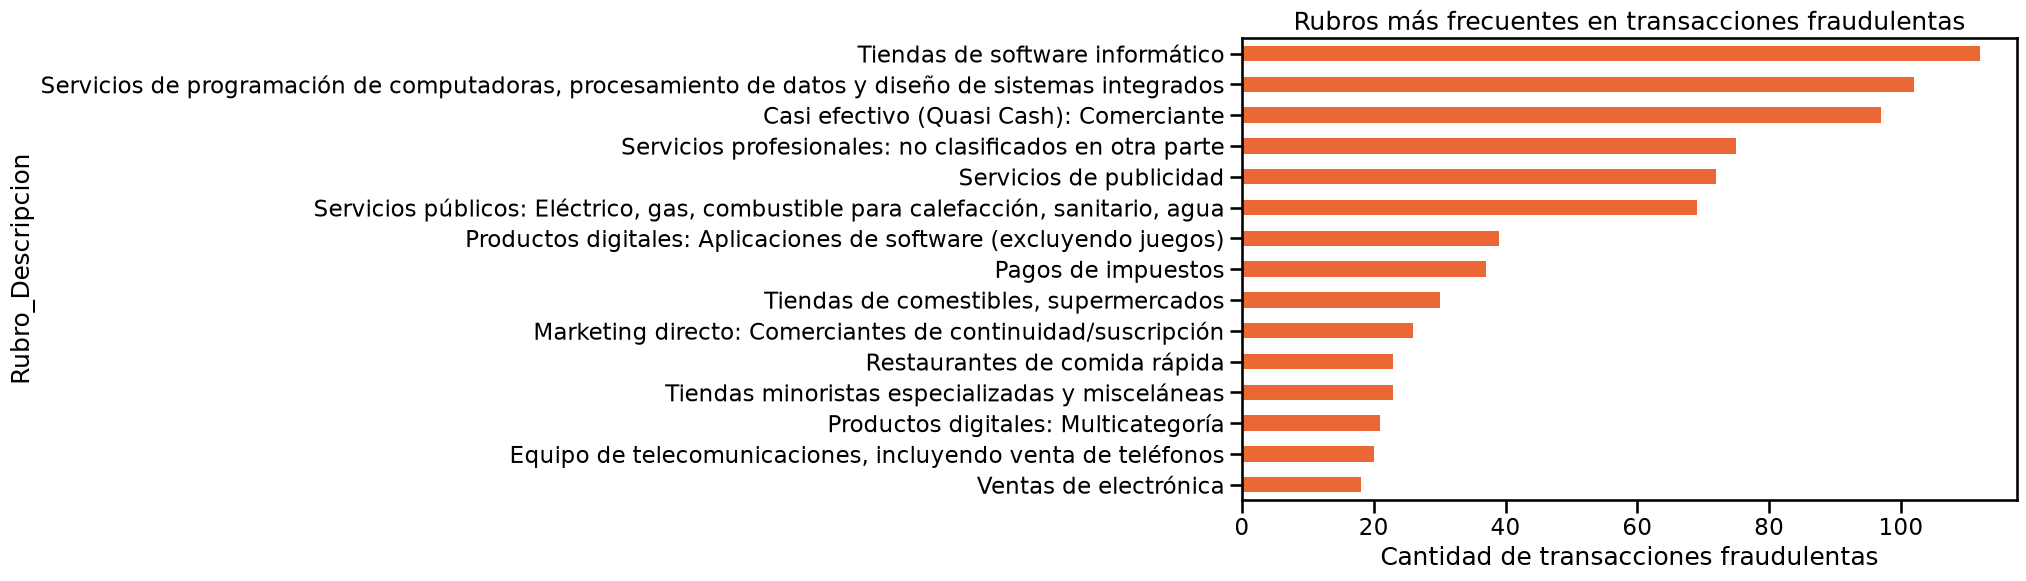

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))
top_rubros_fraude.plot(kind='barh', ax=ax, color='#eb6834')
ax.set_xlabel('Cantidad de transacciones fraudulentas')
ax.set_title('Rubros más frecuentes en transacciones fraudulentas')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Matriz de correlación con la variable target

Se construye una matriz de correlación entre las principales variables
identificadas como relevantes en las secciones anteriores y la variable
objetivo (Es_Fraude). Dado que varias de estas variables son categóricas,
se aplica una codificación previa (numérica o de frecuencia) para poder
incluirlas en el cálculo de correlación, que por definición solo opera sobre
variables numéricas.

=== Correlación de cada variable con Es_Fraude (ordenado) ===
Es_Fraude                  1.000000
Ciudad_TasaFraude          0.502971
Rubro_TasaFraude           0.305161
Movimiento_TasaFraude      0.207947
Trx_Moneda                 0.201196
TipoTerminal_TasaFraude    0.194989
Tiempo_Entre_Trx_Horas     0.022461
Es_Outlier_Importe         0.009144
Trx_Importe               -0.002659
Hora_Dia                  -0.018126
Presencia_Cliente         -0.085381
Name: Es_Fraude, dtype: float64


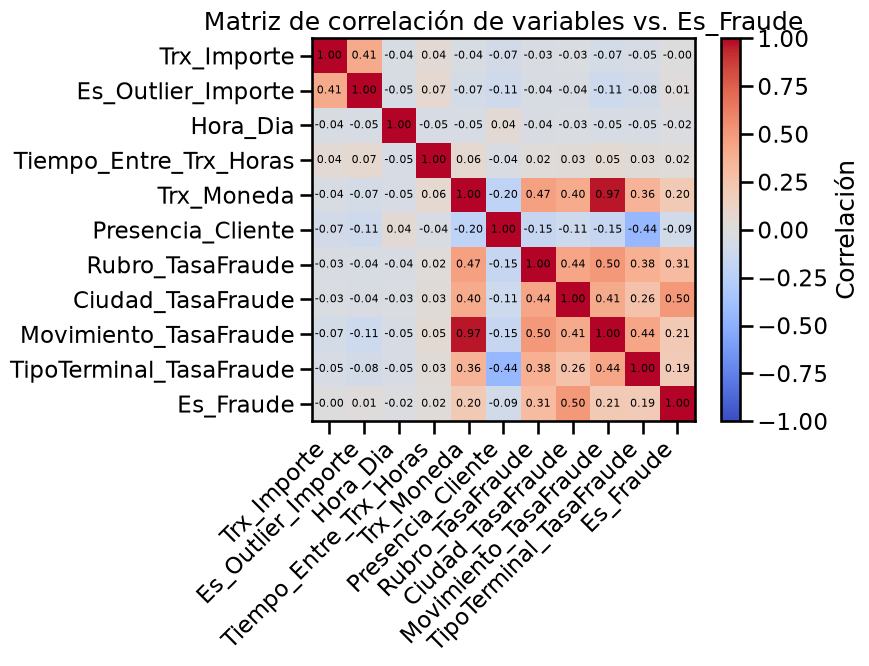

In [74]:
# ============================================
# Matriz de correlación con la variable target
# ============================================

df_corr = pd.DataFrame(index=df.index)

# --- 1. Variables numéricas directas ---
df_corr['Trx_Importe'] = df['Trx_Importe']
df_corr['Es_Outlier_Importe'] = df['Es_Outlier_Importe']
df_corr['Hora_Dia'] = df['Hora_Dia']
df_corr['Tiempo_Entre_Trx_Horas'] = df['Tiempo_Entre_Trx_Horas']
df_corr['Trx_Moneda'] = df['Trx_Moneda']  # 1=Pesos, 2=Dólares

# --- 2. Variables categóricas binarias -> 0/1 ---
df_corr['Presencia_Cliente'] = df['Presencia_Cliente'].map({'Presencial': 1, 'No presencial': 0})

# --- 3. Variables categóricas de alta cardinalidad -> frequency/target encoding ---
# Frequency encoding: reemplaza cada categoría por su tasa de fraude (más informativo que frecuencia simple)
df_corr['Rubro_TasaFraude'] = df['Rubro_Descripcion'].map(
    df.groupby('Rubro_Descripcion')['Es_Fraude'].mean()
)
df_corr['Ciudad_TasaFraude'] = df['Trx_CiudadTerminal'].map(
    df.groupby('Trx_CiudadTerminal')['Es_Fraude'].mean()
)
df_corr['Movimiento_TasaFraude'] = df['Movimiento_Descripcion'].map(
    df.groupby('Movimiento_Descripcion')['Es_Fraude'].mean()
)
df_corr['TipoTerminal_TasaFraude'] = df['Trx_TipoTerminal'].map(
    df.groupby('Trx_TipoTerminal')['Es_Fraude'].mean()
)

# --- 4. Variable target ---
df_corr['Es_Fraude'] = df['Es_Fraude']

# --- 5. Matriz de correlación ---
matriz_corr = df_corr.corr()

print("=== Correlación de cada variable con Es_Fraude (ordenado) ===")
print(matriz_corr['Es_Fraude'].sort_values(ascending=False))

# --- 6. Visualización: heatmap ---
fig, ax = plt.subplots(figsize=(9, 7))
cax = ax.imshow(matriz_corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(matriz_corr.columns)))
ax.set_yticks(range(len(matriz_corr.columns)))
ax.set_xticklabels(matriz_corr.columns, rotation=45, ha='right')
ax.set_yticklabels(matriz_corr.columns)

# Anotar valores dentro de cada celda
for i in range(len(matriz_corr.columns)):
    for j in range(len(matriz_corr.columns)):
        ax.text(j, i, f'{matriz_corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

fig.colorbar(cax, label='Correlación')
ax.set_title('Matriz de correlación de variables vs. Es_Fraude')
plt.tight_layout()
plt.show()

### Matriz de Cramér's V entre variables categóricas


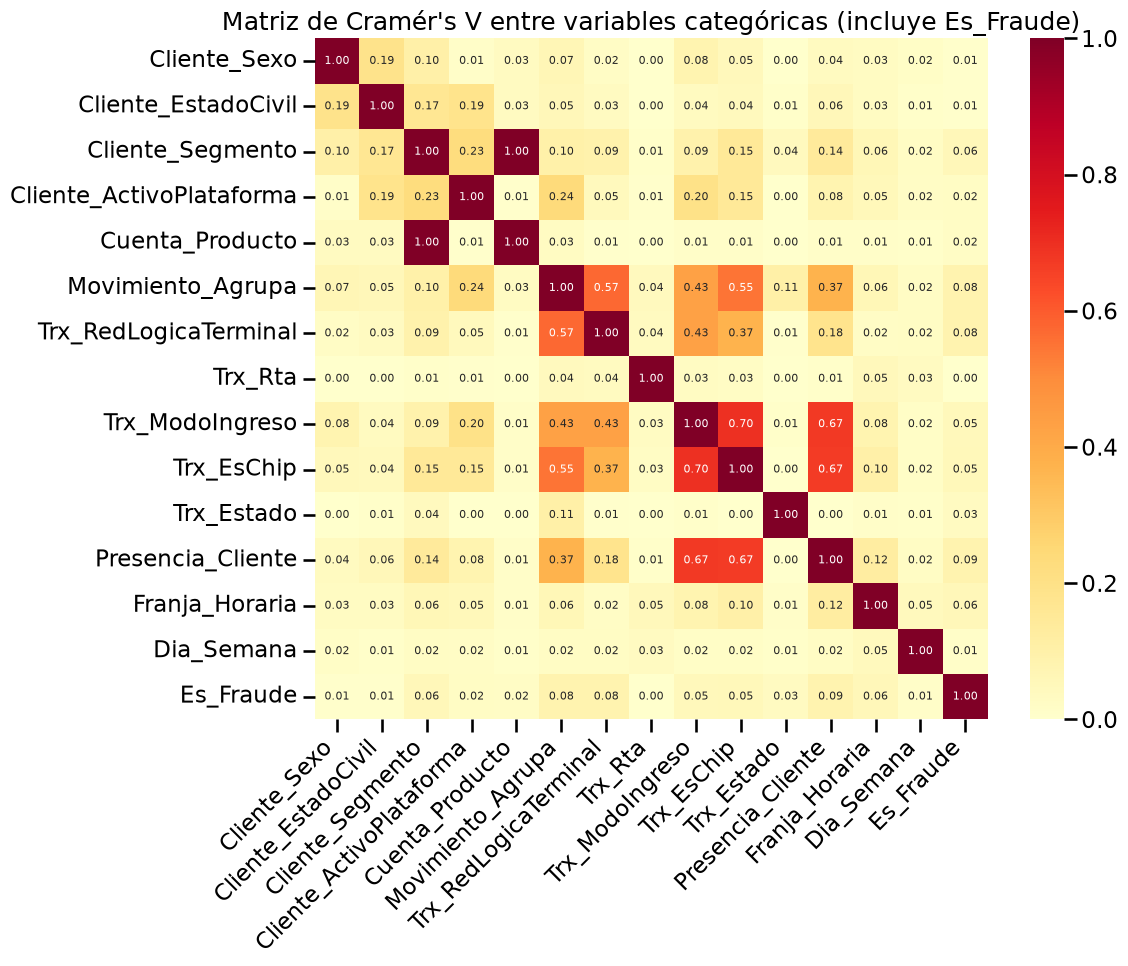

Asociación (Cramér's V) de cada variable categórica con Es_Fraude:
Presencia_Cliente          0.085351
Trx_RedLogicaTerminal      0.084838
Movimiento_Agrupa          0.082573
Cliente_Segmento           0.056239
Franja_Horaria             0.055478
Trx_EsChip                 0.051322
Trx_ModoIngreso            0.050478
Trx_Estado                 0.031748
Cliente_ActivoPlataforma   0.023931
Cuenta_Producto            0.021220
Dia_Semana                 0.014459
Cliente_Sexo               0.006477
Cliente_EstadoCivil        0.006412
Trx_Rta                    0.003049
Name: Es_Fraude, dtype: float64


In [75]:


def cramers_v(x, y):
    """Cramér's V con corrección de sesgo (Bergsma & Wicher, 2013)."""
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla, correction=False)[0]
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

cat_cols = [
    'Cliente_Sexo', 'Cliente_EstadoCivil', 'Cliente_Segmento', 'Cliente_ActivoPlataforma',
    'Cuenta_Producto', 'Movimiento_Agrupa', 'Trx_RedLogicaTerminal', 'Trx_Rta',
    'Trx_ModoIngreso', 'Trx_EsChip', 'Trx_Estado', 'Presencia_Cliente',
    'Franja_Horaria', 'Dia_Semana', 'Es_Fraude'
]

cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1, c2 in itertools.product(cat_cols, cat_cols):
    cramer_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cramer_matrix.astype(float),
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size":8}
)

ax.set_title("Matriz de Cramér's V entre variables categóricas (incluye Es_Fraude)")
ax.set_xticklabels(cramer_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(cramer_matrix.index)

fig.tight_layout()
plt.show()

print("Asociación (Cramér's V) de cada variable categórica con Es_Fraude:")
print(cramer_matrix['Es_Fraude'].drop('Es_Fraude').sort_values(ascending=False))


**Hallazgo — redundancia entre variables de presencialidad:** se detectan asociaciones **fuertes entre variables predictoras entre sí** — en particular `Trx_ModoIngreso` con `Trx_EsChip` (ambas describen, con distinto nivel de detalle, cómo se leyó la tarjeta), y `Presencia_Cliente` con ambas (tiene sentido, ya que `Presencia_Cliente` se construyó a partir de `Trx_ModoIngreso`). También aparece asociación moderada-alta entre `Movimiento_Agrupa` y `Trx_EsChip`/`Trx_RedLogicaTerminal` (el tipo de movimiento condiciona qué canales son posibles). Esto es un indicio claro de **redundancia**: para el modelo, probablemente no haga falta incluir las tres variables de presencialidad (`Trx_ModoIngreso`, `Trx_EsChip`, `Presencia_Cliente`) a la vez, sino elegir la más informativa o combinarlas en una sola.

** `Cuenta_Producto` es casi determinística:** aparece una asociación **perfecta (1.00)** entre `Cuenta_Producto` y `Cliente_Segmento`. Al revisar la tabla cruzada se confirma que **las 125 transacciones con `Cuenta_Producto = 'CuentaCorriente'` (el 0,06% del dataset) corresponden exclusivamente al segmento `S8`** — el resto de los segmentos son 100% `CajaAhorro`. Es decir, `Cuenta_Producto` no aporta información nueva más allá de la ya contenida en `Cliente_Segmento`: son, en la práctica, la misma variable vista desde dos ángulos. Para el modelo, conviene descartar una de las dos (o quedarse con `Cliente_Segmento`, que tiene más granularidad)

Respecto a `Es_Fraude`, ninguna variable categórica individual muestra una asociación fuerte (todas por debajo de un nivel que se consideraría alto) — consistente con lo visto en el resto del análisis: el fraude no se explica bien por una sola variable categórica aislada.

### ¿Correlación lineal o información no lineal? Comparación con Información Mutua

La matriz de correlación anterior solo detecta relaciones **lineales** entre cada variable y `Es_Fraude`. Una variable puede ser muy predictiva del fraude de forma **no lineal** (por ejemplo, si el riesgo aumenta tanto para importes muy bajos como muy altos, o solo por encima de un umbral puntual) y aun así tener una correlación de Pearson casi nula. Para completar el diagnóstico calculamos la **Información Mutua** (`mutual_info_classif`) de cada variable respecto de `Es_Fraude`: a diferencia de la correlación, detecta cualquier tipo de dependencia estadística, lineal o no.

**Importante:** la Información Mutua no está acotada entre -1 y 1 como la correlación, así que no se pueden comparar magnitudes en términos absolutos entre ambas métricas

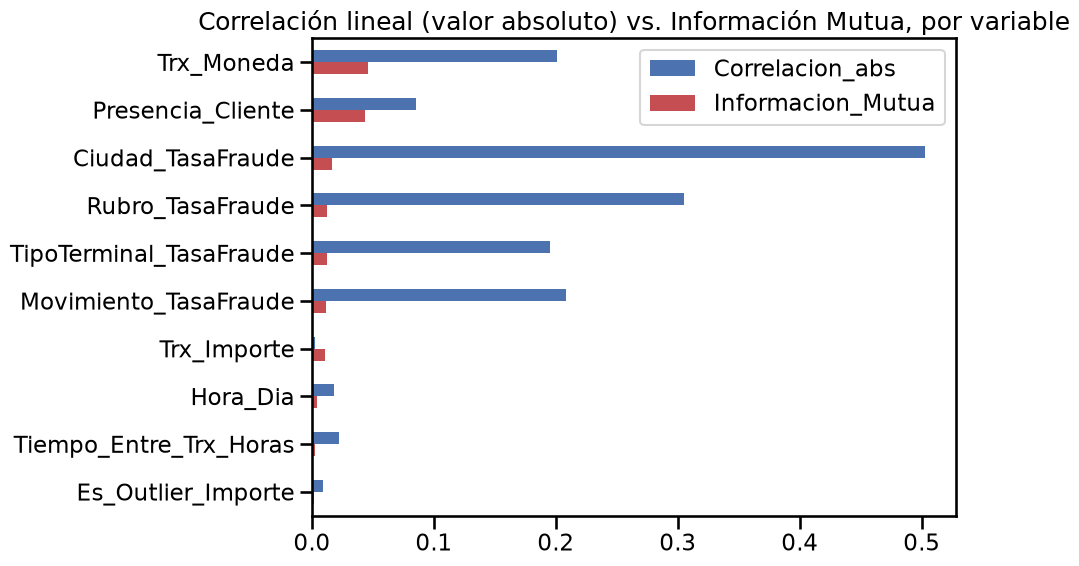

,Correlacion_Pearson,Informacion_Mutua,Rank_Correlacion,Rank_Info_Mutua,Salto_de_ranking
Trx_Moneda,0.201196,0.045756,4,1,3
Presencia_Cliente,-0.085381,0.043528,6,2,4
Ciudad_TasaFraude,0.502971,0.016712,1,3,-2
Rubro_TasaFraude,0.305161,0.012259,2,4,-2
TipoTerminal_TasaFraude,0.194989,0.012020,5,5,0
Movimiento_TasaFraude,0.207947,0.011625,3,6,-3
Trx_Importe,-0.002659,0.010767,10,7,3
Hora_Dia,-0.018126,0.003864,8,8,0
Tiempo_Entre_Trx_Horas,0.022461,0.002288,7,9,-2
Es_Outlier_Importe,0.009144,0.001710,9,10,-1


In [76]:


X_mi = df_corr.drop(columns='Es_Fraude').fillna(0)
y_mi = df_corr['Es_Fraude']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=X_mi.columns, name='Informacion_Mutua')

comparacion = pd.DataFrame({
    'Correlacion_Pearson': matriz_corr['Es_Fraude'].drop('Es_Fraude'),
    'Informacion_Mutua': mi_series
})
comparacion['Correlacion_abs'] = comparacion['Correlacion_Pearson'].abs()
comparacion['Rank_Correlacion'] = comparacion['Correlacion_abs'].rank(ascending=False).astype(int)
comparacion['Rank_Info_Mutua'] = comparacion['Informacion_Mutua'].rank(ascending=False).astype(int)
comparacion['Salto_de_ranking'] = comparacion['Rank_Correlacion'] - comparacion['Rank_Info_Mutua']
comparacion = comparacion.sort_values('Informacion_Mutua', ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
comparacion[['Correlacion_abs', 'Informacion_Mutua']].plot(kind='barh', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_title('Correlación lineal (valor absoluto) vs. Información Mutua, por variable')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

comparacion[['Correlacion_Pearson', 'Informacion_Mutua', 'Rank_Correlacion', 'Rank_Info_Mutua', 'Salto_de_ranking']]

**`Trx_Importe`:** es el ejemplo más claro de señal **no lineal**. Su correlación de Pearson con `Es_Fraude` es prácticamente nula (cercana a 0, el peor ranking entre todas las variables por correlación), pero su Información Mutua es notoriamente más alta y su ranking mejora varias posiciones. Esto coincide exactamente con lo que habíamos visto en la sección de outliers: **la tasa de fraude no crece de forma proporcional con el importe** (que es lo que mediría la correlación), sino que se concentra en la cola de importes atípicamente altos — una relación de umbral, no lineal, que la correlación de Pearson es ciega a detectar pero la Información Mutua sí capta.

**Hallazgo — `Presencia_Cliente` y `Trx_Moneda`:** también mejoran su ranking en Información Mutua respecto del de correlación, sugiriendo que aportan más valor predictivo del que su correlación lineal por sí sola indicaría.


## Conclusiones del EDA: valor predictivo de las variables y próximos pasos

### Variables que continuamos usando (ordenadas de mayor a menor valor predictivo)

1. **`Trx_Moneda`** — la variable individual más informativa: 1° en Información Mutua y tasa de fraude en dólares (9,45%) ~28 veces superior a la de pesos (0,34%).
2. **`Trx_CiudadTerminal`** — la que mostró mayor correlación con el target al explorarla (a través de su tasa de fraude por categoría, 0,50); ciudades puntuales concentran tasas de fraude extremas (Quibdo 98%, Dublin 24%, Mountain View ~19%).
3. **`Presencia_Cliente`** — 2° en Información Mutua; resume `Trx_ModoIngreso` y `Trx_EsChip` (redundantes entre sí, Cramér's V 0,67–0,70). Se asocia directamente con `Trx_TipoTerminal = 11` (e-commerce con débito), que concentra el 64,9% de los fraudes.
4. **`Trx_RubroRed`** — correlación 0,305 al explorarla por categoría; rubros como Servicios de citas (50%), Publicidad (34,6%) y Programación (30,8%) muestran tasas de fraude muy por encima del promedio.
5. **`Trx_TipoTerminal`** — correlación moderada (0,195), pero con una concentración muy fuerte en el canal e-commerce (tipo 11).
6. **`Movimiento_Codigo` / `Movimiento_Agrupa`** — correlación 0,208 al explorarla por categoría; "Compra en el exterior con débito" destaca con 9,56% de tasa de fraude.
7. **`Trx_Importe`** — correlación lineal casi nula, pero con señal **no lineal** real (mejora del puesto 10 al 7 en Información Mutua): el riesgo se concentra en la cola de importes atípicamente altos, no crece de forma proporcional. Mantener transformado (log) y/o combinado con `Es_Outlier_Importe`.
8. **`Tiempo_Entre_Trx_Horas`** — correlación baja (0,022), pero cualitativamente relevante: mediana de 0,63 hs entre transacciones en casos de fraude vs. 6,9 hs en no-fraude (patrón de "ráfaga").
9. **`Hora_Dia` / `Franja_Horaria`** — señal más débil (correlación -0,018), pero el fraude se desvía del horario habitual de actividad; se conserva como variable secundaria/de interacción.

> **Nota sobre `Trx_CiudadTerminal`, `Trx_RubroRed`, `Trx_TipoTerminal` y `Movimiento_Codigo`:** en el EDA las exploramos calculando la tasa de fraude por categoría (`Ciudad_TasaFraude`, `Rubro_TasaFraude`, etc.) para poder medir su correlación con el target. Esas variables derivadas cumplieron su función de diagnóstico, pero no las vamos a llevar tal cual al modelo por el riesgo de fuga de información que implican (se calculan usando el propio `Es_Fraude`). Lo que continúa a la siguiente etapa son las **variables originales**, y en el momento de modelar se decidirá cómo codificarlas correctamente (one-hot, agrupación de categorías, o un target encoding calculado solo con datos de entrenamiento).

### Variables que descartamos (y por qué)

- **`Trx_ModoIngreso` y `Trx_EsChip`** — redundantes entre sí y con `Presencia_Cliente` (Cramér's V 0,67–0,70); nos quedamos solo con `Presencia_Cliente`.
- **`Cuenta_Producto`** — asociación perfecta (Cramér's V = 1,00) con `Cliente_Segmento` (las únicas cuentas corrientes son, exactamente, el segmento S8); no aporta información nueva.
- **`Cliente_Sexo` y `Cliente_EstadoCivil`** — Cramér's V con el target prácticamente nulo (0,006 en ambos casos).
- **`Cliente_ActivoPlataforma`** — asociación baja con el target (Cramér's V 0,024).
- **`Trx_Rta`** — asociación mínima con el target (Cramér's V 0,003).
- **`Dia_Semana`** — señal débil de forma aislada (Cramér's V 0,014); se descarta como variable individual, aunque puede reconsiderarse combinada con otras variables temporales.
- **`Es_Outlier_Importe`** — último lugar tanto en correlación como en Información Mutua; queda subsumida por `Trx_Importe` (transformado), que captura la misma idea con más matices.
- **`Cliente_CodigoPostal` y `Trx_TerminalRed`** — cardinalidad demasiado alta para evaluar de forma confiable en esta etapa; se descartan por ahora, con posibilidad de retomarlas agregadas por zona más adelante.

### Qué hacer con los datos faltantes de cara al modelo

- **`Cliente_Sexo`, `Cliente_EstadoCivil`, `Cliente_Segmento`** (faltantes siempre juntas, mismo cliente): serán imputados usando el propio historial del cliente (`ffill`/`bfill` agrupado por `Cliente_Id`), aprovechando que el dato sí existía en otras transacciones suyas. Mantener este mismo criterio para datos nuevos que ingresen al pipeline.
- **`Trx_CiudadTerminal`**: no se imputó con un valor inventado; se creó la categoría explícita `SIN_TERMINAL` para las transacciones sin terminal física (Home Banking). Esta información ya queda capturada de forma más general por `Presencia_Cliente`, por lo que no hace falta una variable adicional — queda solo como sugerencia si en el futuro se necesitara aislar específicamente el canal digital.
- **Duplicados exactos (148 filas)**: ya eliminados; se verificó que eran totalmente identicos, por lo que no se perdió información.
- **Códigos "vacíos" que en realidad son categorías válidas** (por ejemplo `Trx_RubroRed = -1` para "sin rubro / no aplica"): no se trataron como nulos ni se imputaron, porque no lo son — son una codificación legítima del diccionario de datos, y se mantuvieron así en todo el análisis.